# Selección de variables: de la matriz de partida a las matrices finales

**Predicción del precio horario del mercado diario español · Trabajo Fin de Máster**

---

## Qué hace este notebook y qué no

Documenta **una sola cosa**: qué columnas entran en las matrices de entrenamiento, cuáles se
quedan fuera y por qué. Nada más.

El análisis exploratorio —el contraste entre fuentes, el perfil de valores ausentes, los
descriptivos, los valores extremos, la relación entre variables— está en el notebook de EDA y
no se repite aquí. Este notebook **parte de sus conclusiones** y las aplica.

La regla que gobierna su contenido: **una operación solo aparece si cambia el conjunto de
columnas, o si justifica directamente que una columna salga.** Si un análisis no termina en una
decisión sobre columnas, no está aquí.

## Cómo leerlo

Cada paso tiene la misma forma:

> **qué se hace y por qué** · **la operación** · **la tabla de control**

La tabla de control imprime siempre lo mismo: columnas antes, **las que salen listadas una a
una con su motivo y su evidencia**, las que entran, y columnas después.

El registro **calcula la diferencia**, no la declara: se le pasa el conjunto resultante y él
deduce qué cambió. Ninguna columna puede desaparecer sin quedar anotada, y si sale sin motivo
asignado la comprobación final falla.

## Protocolo de partición

| tramo | fechas | uso |
|---|---|---|
| entrenamiento | hasta el 31-12-2024 | **todas** las decisiones se toman aquí |
| validación | 2025 completo | solo para medir deriva de distribución |
| test | desde el 01-01-2026 | **no se consulta en ningún momento** |

Un umbral fijado observando el tramo de test es una fuga de información tan real como incluir
una variable publicada después del cierre del mercado, y bastante más difícil de detectar.

## 0 · Configuración

In [1]:
import hashlib
import json
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
sys.path.append(str(REPO / "scripts"))

import depuracion as dep
from construir_matriz import construir
from apagon import imputar
from depurar_matriz import (depurar, residuo, perfil_series, corte_temporal,
                            UMBRAL_ARRANQUE_TARDIO)
from procedencia import origen

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 200)

TARGET = "target_price"
SALIDA = REPO / "data" / "gold"
SALIDA.mkdir(parents=True, exist_ok=True)

# Umbrales, todos en un sitio: ninguna decisión depende de un número escondido
# en mitad del notebook.
UMBRAL_DERIVA      = 3.0     # sigmas del tramo de entrenamiento
UMBRAL_REDUNDANCIA = 0.95    # |r| a partir del cual dos columnas son la misma
CORTE_MODERNA      = pd.Timestamp("2023-01-01")
N_MINIMA           = 25

# Del bloque de materias primas se emplea el precio del gas del mercado ibérico,
# que es la referencia del mercado español y la de publicación más estable.
COMMODITIES = ["gas_mibgas"]

print("Configuración cargada.")

Configuración cargada.


## 1 · El registro de columnas

Toda la trazabilidad descansa aquí. Mantiene el conjunto candidato —el *pool*— y registra cada
cambio como diferencia entre el conjunto anterior y el nuevo.

In [2]:
class RegistroColumnas:
    """Libro mayor de columnas: registra altas y bajas paso a paso."""

    def __init__(self, columnas, etiqueta="matriz de partida"):
        self.pool = list(dict.fromkeys(columnas))
        self.libro = {c: {"variable": c, "entra_en": etiqueta, "sale_en": None,
                          "motivo": None, "evidencia": None, "proposito": None}
                      for c in self.pool}
        self.pasos = []

    def aplicar(self, paso, pool_nuevo, motivo=None, evidencia=None,
                propositos=None, nota=""):
        pool_nuevo = list(dict.fromkeys(pool_nuevo))
        antes, ahora = set(self.pool), set(pool_nuevo)
        salen, entran = sorted(antes - ahora), sorted(ahora - antes)
        evidencia, propositos = evidencia or {}, propositos or {}

        for c in salen:
            m = motivo.get(c) if isinstance(motivo, dict) else motivo
            r = self.libro.setdefault(c, {"variable": c, "entra_en": "?"})
            r.update({"sale_en": paso, "motivo": m or "SIN MOTIVO",
                      "evidencia": evidencia.get(c, r.get("evidencia") or "")})

        for c in entran:
            if c in self.libro and self.libro[c].get("sale_en"):
                self.libro[c].update({"sale_en": None, "motivo": None,
                                      "evidencia": "reincorporada"})
            else:
                self.libro[c] = {"variable": c, "entra_en": paso, "sale_en": None,
                                 "motivo": None, "evidencia": evidencia.get(c, ""),
                                 "proposito": propositos.get(c, "")}

        self.pasos.append({"paso": paso, "antes": len(antes), "salen": len(salen),
                           "entran": len(entran), "despues": len(ahora), "nota": nota})
        self.pool = pool_nuevo
        self._imprimir(paso, salen, entran, len(antes), len(ahora), nota)

    def _imprimir(self, paso, salen, entran, n0, n1, nota):
        print(f"\n{'=' * 80}\n{paso}\n{'=' * 80}")
        if nota:
            print(f"  {nota}\n")
        print(f"  columnas antes {n0:4d}   salen {len(salen):3d}   "
              f"entran {len(entran):3d}   después {n1:4d}")
        if salen:
            print("\n  ---- SALEN ----")
            for c in salen:
                e = self.libro[c].get("evidencia") or ""
                print(f"    -  {c:42s} {self.libro[c]['motivo']}")
                if e:
                    print(f"       {'':42s} {e}")
        if entran:
            print("\n  ---- ENTRAN ----")
            for c in entran:
                p = self.libro[c].get("proposito") or self.libro[c].get("evidencia") or ""
                print(f"    +  {c:42s} {p}")

    def resumen_pasos(self):
        return pd.DataFrame(self.pasos)

    def libro_mayor(self, destinos=None):
        df = pd.DataFrame(self.libro.values())
        df["estado"] = np.where(df["sale_en"].isna(), "en la matriz", "descartada")
        if destinos:
            for nombre, cols in destinos.items():
                df[f"en_{nombre}"] = df["variable"].isin(cols).map({True: "si", False: ""})
        try:
            df["tabla_origen"] = df["variable"].map(origen)
        except Exception:
            df["tabla_origen"] = ""
        orden = ["variable", "bloque", "tabla_origen", "estado", "entra_en", "proposito",
                 "sale_en", "motivo", "evidencia"]
        orden += [c for c in df.columns if c not in orden]
        return df[[c for c in orden if c in df.columns]].sort_values(
            ["estado", "sale_en", "variable"], na_position="first")


print("Registro definido.")

Registro definido.


# PARTE I · El punto de partida

## 2 · La matriz de partida

Se construye leyendo la base de datos **sin ningún filtro**. Es el conjunto completo de
columnas candidatas, y la referencia contra la que se mide todo lo que viene después.

Se guarda además una copia intacta con el nombre `crudo`: hay un diagnóstico —el del paso 7—
que solo tiene sentido antes de resolver los valores ausentes, porque después un cero fabricado
es indistinguible de un cero legítimo.

In [3]:
datos = construir()
datos["ts"] = datos["fecha_objetivo"] + pd.to_timedelta(datos["hora"], unit="h")
datos = datos.sort_values("ts").reset_index(drop=True)
crudo = datos.copy()

TRAIN = datos["split"] == "train"
VAL   = datos["split"] == "validation"
TEST  = datos["split"] == "test"

print(f"Matriz de partida: {datos.shape[0]:,} filas x {datos.shape[1]} columnas\n")
print(datos.groupby("split", sort=False).agg(
    filas=("ts", "size"), dias=("fecha_objetivo", "nunique"),
    desde=("fecha_objetivo", "min"), hasta=("fecha_objetivo", "max")).to_string())
print(f"\nDecisiones tomadas sobre {TRAIN.sum():,} filas de entrenamiento.")

Leyendo de cache: C:\Users\torgi\proyectos\tfm-energia\data\bronze\matriz_cruda.parquet  (usa forzar=True para reconstruir)
Matriz de partida: 57,689 filas x 190 columnas

            filas  dias      desde      hasta
split                                        
train       43867  1828 2020-01-01 2025-01-01
validation   8759   365 2025-01-02 2026-01-01
test         5063   211 2026-01-02 2026-07-31

Decisiones tomadas sobre 43,867 filas de entrenamiento.


## 3 · De dónde sale cada columna

Las columnas se clasifican en **tres ejes simultáneos**, y los tres hacen falta para leer los
pasos siguientes:

- **Bloque** — qué mide la columna.
- **Naturaleza** — si la publica una fuente, si se construye en el proceso, si es una
  observación reubicada en el tiempo, o si la calcula la base de datos.
- **Disponibilidad** — **si está publicada antes de que cierre el mercado**.

El tercero es el que decide si una variable puede usarse. El mercado diario cierra a las 12:00
del día anterior a aquel cuyo precio se predice, de modo que una variable solo es legítima si
existe antes de ese instante. No basta con que esté en la base de datos: tiene que estar
publicada a tiempo.

La matriz codifica ese momento en el propio nombre de cada columna:

| sufijo | significa |
|---|---|
| `_prev` | previsión publicada **para el día objetivo**, antes de las 11:00 del día anterior |
| `_D` | dato correspondiente al día de predicción, publicado la víspera |
| `_Dm1`, `_Dm2`, `_Dm6` | observación real de días anteriores |
| `_meteo` | canal meteorológico empalmado |
| `_sin`, `_cos` | codificación cíclica de una variable de calendario |

**Ninguna columna se refiere al día objetivo salvo las de previsión**, que por definición se
publican antes. Es la traducción operativa de la frontera de no fuga.

In [4]:
COLS_CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split"]
BANDERAS     = ("imputado_apagon", "ventana_pisa_apagon",
                "pbf_publicado_D", "pbf_completo_D")
# Magnitudes que ninguna fuente publica y se obtienen combinando dos. Se identifican
# por su raíz porque llevan sufijo de desfase: `solar_fv_mw_Dm1`.
RECONSTRUIDAS = ("solar_fv_mw", "hydro_dispatch_mw", "calc_")
AGREGADAS_BD  = ("total_net_flow_mw", "gen_peninsular_mw")


def raiz(c):
    for suf in ("_Dm1", "_Dm2", "_Dm6", "_D"):
        if c.endswith(suf):
            return c[: -len(suf)]
    return c


def clasificar(c):
    """Devuelve (bloque, naturaleza, disponibilidad). El orden importa: varios
    patrones se solapan y el más específico va primero."""
    b = raiz(c)
    if c in COLS_CONTROL:  return "control", "eje temporal", "no aplica"
    if c == TARGET:        return "objetivo", "construida", "es lo que se predice"
    if c in BANDERAS:      return "trazabilidad", "construida", "no aplica"

    if c.startswith("es_esios_"):
        return "precio: referencia de persistencia", "desfasada", "publicado antes del cierre"
    if c.startswith("spread_"):
        return "precio: diferencial entre zonas", "construida", "publicado antes del cierre"
    if c.endswith("_entsoe_D"):
        return "precio: mercados vecinos", "desfasada", "publicado antes del cierre"

    if c.endswith(("_prev", "_prev_mw")):
        return "previsión para el día objetivo", "de fuente", "publicada antes del cierre"
    if c.endswith("_fc"):
        return "meteorología: previsión cruda", "de fuente", "publicada antes del cierre"
    if c == "meteo_es_forecast":
        return "meteorología: procedencia del canal", "construida", "conocida de antemano"
    if c.endswith("_meteo"):
        return "meteorología: canal empalmado", "construida", "publicada antes del cierre"
    if "_met_" in c:
        return "meteorología: reanálisis desfasado", "desfasada", "observado y publicado"

    if c.endswith(("_sin", "_cos")):
        return "calendario: codificación cíclica", "construida", "conocida de antemano"
    if c.startswith("d1_regimen_"):
        return "régimen regulatorio", "construida", "conocida de antemano"
    if c == "hora" or c.startswith("d1_"):
        return "calendario", "construida", "conocida de antemano"

    if c.startswith(("gas_", "co2_")):
        return "materias primas", "de fuente", "cierre del día anterior"
    if c.startswith("capinst_"):
        return "capacidad instalada", "de fuente", "estructural"
    if c.startswith("capdisp_"):
        return "capacidad disponible", "de fuente", "declarada antes del cierre"

    if b.startswith(RECONSTRUIDAS):
        return "generación: reconstruida entre fuentes", "construida", "observada y publicada"
    if b in AGREGADAS_BD or b.startswith("net_flow_"):
        return "demanda e intercambios: agregado", "derivada en la base", "observado y publicado"

    if c.startswith(("pdbc_", "pbf", "bil_")):
        return "programas de casación", "desfasada", "publicado antes del cierre"
    if c.endswith(("_Dm1", "_Dm2", "_Dm6")):
        return "estado real de días anteriores", "desfasada", "observado y publicado"
    if c.endswith("_D"):
        return "estado real del día de predicción", "desfasada", "publicado antes del cierre"

    return "SIN CLASIFICAR", "SIN CLASIFICAR", "SIN CLASIFICAR"


mapa = pd.DataFrame([{"variable": c, "bloque": b, "naturaleza": n, "disponibilidad": d}
                     for c in datos.columns for b, n, d in [clasificar(c)]])

display(mapa.groupby(["bloque", "naturaleza", "disponibilidad"])
        .agg(columnas=("variable", "size"),
             ejemplos=("variable", lambda s: ", ".join(sorted(s)[:3])))
        .reset_index().sort_values("columnas", ascending=False).reset_index(drop=True))

for eje in ("naturaleza", "disponibilidad"):
    print(f"Reparto por {eje}:")
    print(mapa.groupby(eje).size().rename("columnas")
          .sort_values(ascending=False).to_string())
    print()

n_obj = int((mapa["bloque"] == "previsión para el día objetivo").sum())
print(f"De las {len(mapa)} columnas, solo {n_obj} se refieren al día que hay que predecir.")
print("Todo lo demás es historia del sistema o información conocida de antemano.")

,bloque,naturaleza,disponibilidad,columnas,ejemplos
0,programas de casación,desfasada,publicado antes del cierre,37,"bil_direct_consumer_mw_D, bil_generic_buy_mw_D..."
1,estado real de días anteriores,desfasada,observado y publicado,36,"biomass_mw_Dm1, biomass_mw_Dm6, entsoe_load_Dm1"
2,capacidad instalada,de fuente,estructural,23,"capinst_autoconsume_battery_mw, capinst_autoco..."
3,meteorología: reanálisis desfasado,desfasada,observado y publicado,20,"d2m_mean_met_Dm1, d2m_mean_met_Dm2, msl_mean_m..."
4,precio: mercados vecinos,desfasada,publicado antes del cierre,10,"at_entsoe_D, be_entsoe_D, ch_entsoe_D"
5,meteorología: previsión cruda,de fuente,publicada antes del cierre,8,"d2m_fc, msl_fc, ssrd_fc"
6,calendario: codificación cíclica,construida,conocida de antemano,8,"d1_dow_cos, d1_dow_sin, d1_doy_cos"
7,calendario,construida,conocida de antemano,7,"d1_dow, d1_es_puente, d1_is_festivo"
8,meteorología: canal empalmado,construida,publicada antes del cierre,7,"d2m_meteo, msl_meteo, ssrd_meteo"
9,capacidad disponible,de fuente,declarada antes del cierre,6,"capdisp_ccgt_mw, capdisp_coal_antracita_mw, ca..."


Reparto por naturaleza:
naturaleza
desfasada              106
de fuente               42
construida              34
derivada en la base      4
eje temporal             4

Reparto por disponibilidad:
disponibilidad
observado y publicado         60
publicado antes del cierre    53
estructural                   23
publicada antes del cierre    19
conocida de antemano          17
declarada antes del cierre     6
no aplica                      6
observada y publicada          4
cierre del día anterior        1
es lo que se predice           1

De las 190 columnas, solo 4 se refieren al día que hay que predecir.
Todo lo demás es historia del sistema o información conocida de antemano.


### 3.1 · Todas las columnas, listadas por bloque

El listado completo, para poder responder a *"¿qué mide exactamente esta variable y cuándo está
disponible?"* sobre cualquiera de las columnas de partida. En la memoria va al anexo.

La comprobación que lo acompaña es la que hace fiable todo lo demás: si una columna no encaja
en ningún patrón queda marcada como **sin clasificar** y el notebook lo dice en voz alta. Una
columna sin clasificar no es un detalle cosmético: es una variable de la que no se sabe si
respeta la frontera de no fuga.

In [5]:
for bloque_n, sub in mapa.groupby("bloque"):
    print("=" * 78)
    print(f"{bloque_n.upper()}   ({len(sub)} columnas)")
    print(f"   naturaleza     : {', '.join(sorted(sub['naturaleza'].unique()))}")
    print(f"   disponibilidad : {', '.join(sorted(sub['disponibilidad'].unique()))}")
    print()
    print(textwrap.fill(" · ".join(sorted(sub["variable"])), width=76,
                        initial_indent="   ", subsequent_indent="   "))
    print()

sin_clas = mapa.loc[mapa["bloque"] == "SIN CLASIFICAR", "variable"].tolist()
if sin_clas:
    print("!" * 78)
    print(f"REVISAR — {len(sin_clas)} columnas sin clasificar:")
    for c in sin_clas:
        print(f"    {c}")
    print("!" * 78)
else:
    print("Todas las columnas están clasificadas por bloque, naturaleza y disponibilidad.")

mapa.to_csv(SALIDA / "mapa_columnas_matriz_partida.csv", index=False, encoding="utf-8")

CALENDARIO   (7 columnas)
   naturaleza     : construida
   disponibilidad : conocida de antemano

   d1_dow · d1_es_puente · d1_is_festivo · d1_is_weekend · d1_month ·
   d1_vispera_festivo · hora

CALENDARIO: CODIFICACIÓN CÍCLICA   (8 columnas)
   naturaleza     : construida
   disponibilidad : conocida de antemano

   d1_dow_cos · d1_dow_sin · d1_doy_cos · d1_doy_sin · d1_month_cos ·
   d1_month_sin · hora_cos · hora_sin

CAPACIDAD DISPONIBLE   (6 columnas)
   naturaleza     : de fuente
   disponibilidad : declarada antes del cierre

   capdisp_ccgt_mw · capdisp_coal_antracita_mw · capdisp_fuel_mw ·
   capdisp_hydro_mw · capdisp_nuclear_mw · capdisp_pump_mw

CAPACIDAD INSTALADA   (23 columnas)
   naturaleza     : de fuente
   disponibilidad : estructural

   capinst_autoconsume_battery_mw · capinst_autoconsume_solar_pv_mw ·
   capinst_battery_hybrid_mw · capinst_ccgt_mw · capinst_coal_mw ·
   capinst_cogeneration_mw · capinst_fuel_mw · capinst_hydro_mw ·
   capinst_nuclear_mw · capi

## 4 · Las columnas construidas y qué problema resuelve cada una

El subconjunto que **no viene de ninguna fuente**. Su justificación es distinta: una columna de
fuente está porque el sistema eléctrico la produce; una construida está porque se decidió que
hacía falta.

**Calendario y codificación cíclica.** Hora, día de la semana, mes, festivo, puente y víspera,
más la codificación en seno y coseno del día, el mes, el día del año y la hora. La demanda tiene
una estructura semanal y anual muy marcada, y sin estas variables el modelo tendría que
inferirla de la propia demanda. La codificación cíclica resuelve además un problema concreto:
en codificación entera, diciembre y enero, o las 23:00 y las 00:00, son la mayor distancia
posible, cuando en realidad son contiguos.

**Régimen regulatorio.** Señala los periodos en que cambiaron las reglas del mercado. Sin ellos
un cambio de regulación se confundiría con un cambio real del sistema.

**Diferenciales entre zonas.** Resumen en una columna el acoplamiento entre mercados vecinos,
que de otro modo obligaría al modelo a comparar dos variables para deducir lo mismo.

**Generación reconstruida entre fuentes.** Magnitudes que ninguna fuente publica directamente:
la fotovoltaica pura, obtenida restando la termosolar al agregado europeo, y la hidráulica
despachable, que suma embalse y generación por bombeo. El razonamiento de cada una está en el
notebook de EDA.

**Canal meteorológico y su procedencia.** El histórico de previsión no cubre toda la ventana.
Usar el dato meteorológico real en su lugar introduciría una asimetría grave: el modelo
aprendería con una meteorología perfecta que en producción nunca tendrá, porque del día a
predecir solo existe la previsión. El canal empalma ambas fuentes y una variable indica cuál se
está usando en cada fila. **Esa variable es una característica de pleno derecho**, no un
metadato: la calidad del dato de entrada es información relevante.

**Banderas de trazabilidad.** Grupo aparte: marcan qué filas fueron reparadas. **No son
características y no entran como predictores.**

In [6]:
PROPOSITO = {
    "calendario": "estructura semanal y anual de la demanda",
    "calendario: codificación cíclica":
        "hace contiguos el salto de diciembre a enero y el de las 23:00 a las 00:00",
    "régimen regulatorio": "distinguir un cambio de reglas de un cambio del sistema",
    "precio: diferencial entre zonas": "resume el acoplamiento entre mercados vecinos",
    "precio: referencia de persistencia":
        "el precio ya publicado al predecir; es la referencia contra la que se mide todo",
    "precio: mercados vecinos": "precio de los mercados acoplados",
    "meteorología: canal empalmado": "misma variable con la fuente disponible en cada fecha",
    "meteorología: procedencia del canal": "indica si la fila usa previsión o reconstrucción",
    "meteorología: previsión cruda": "previsión original, sustituida por el canal empalmado",
    "meteorología: reanálisis desfasado": "observación meteorológica de días anteriores",
    "generación: reconstruida entre fuentes":
        "magnitud que ninguna fuente publica y se obtiene combinando dos",
    "demanda e intercambios: agregado": "suma calculada por la base de datos",
    "estado real de días anteriores": "el sistema tal y como se observó, ya publicado",
    "estado real del día de predicción": "información del día en curso publicada antes del cierre",
    "programas de casación": "programa del día de predicción, publicado antes del cierre",
    "previsión para el día objetivo": "la única información referida al día que se predice",
    "materias primas": "coste del combustible que fija el precio marginal",
    "capacidad instalada": "parque disponible, de evolución estructural",
    "capacidad disponible": "potencia declarada disponible por tecnología",
    "trazabilidad": "marca de fila reparada — NO es un predictor",
    "objetivo": "precio horario del mercado diario del día siguiente",
    "control": "eje temporal y partición",
}

mapa["proposito"] = mapa["bloque"].map(PROPOSITO)
construidas = mapa[mapa["naturaleza"] == "construida"]
print(f"Columnas construidas: {len(construidas)} de {len(mapa)}\n")
display(construidas.groupby(["bloque", "proposito"])
        .agg(columnas=("variable", "size"),
             variables=("variable", lambda s: ", ".join(sorted(s))))
        .reset_index())

reg = RegistroColumnas([c for c in datos.columns if c not in COLS_CONTROL])
for _, r in mapa.iterrows():
    if r["variable"] in reg.libro:
        reg.libro[r["variable"]]["proposito"] = r["proposito"]
        reg.libro[r["variable"]]["bloque"] = r["bloque"]

print(f"\nPool inicial: {len(reg.pool)} columnas")
print(f"Fuera del pool desde el principio (identifican la fila): {COLS_CONTROL}")

Columnas construidas: 34 de 190



,bloque,proposito,columnas,variables
0,calendario,estructura semanal y anual de la demanda,7,"d1_dow, d1_es_puente, d1_is_festivo, d1_is_wee..."
1,calendario: codificación cíclica,hace contiguos el salto de diciembre a enero y...,8,"d1_dow_cos, d1_dow_sin, d1_doy_cos, d1_doy_sin..."
2,generación: reconstruida entre fuentes,magnitud que ninguna fuente publica y se obtie...,4,"hydro_dispatch_mw_Dm1, hydro_dispatch_mw_Dm6, ..."
3,meteorología: canal empalmado,misma variable con la fuente disponible en cad...,7,"d2m_meteo, msl_meteo, ssrd_meteo, t2m_meteo, t..."
4,meteorología: procedencia del canal,indica si la fila usa previsión o reconstrucción,1,meteo_es_forecast
5,objetivo,precio horario del mercado diario del día sigu...,1,target_price
6,precio: diferencial entre zonas,resume el acoplamiento entre mercados vecinos,3,"spread_es_de_D, spread_es_fr_D, spread_es_pt_D"
7,régimen regulatorio,distinguir un cambio de reglas de un cambio de...,1,d1_regimen_tope_gas
8,trazabilidad,marca de fila reparada — NO es un predictor,2,"pbf_completo_D, pbf_publicado_D"



Pool inicial: 186 columnas
Fuera del pool desde el principio (identifican la fila): ['fecha_pred', 'fecha_objetivo', 'ts', 'split']


# PARTE II · Los pasos

A partir de aquí, cada apartado quita columnas o las marca para que las quiten las matrices
podadas. Nada más.

## 5 · Paso 0 — Alcance del bloque de materias primas

Del bloque de materias primas se emplea únicamente el precio del gas del mercado ibérico. Es la
referencia del mercado español, la que fija el coste marginal del ciclo combinado en las horas
en que esa tecnología resulta marginal, y la de publicación más estable de las disponibles.

In [7]:
def es_commodity(col):
    """Columnas del bloque de materias primas."""
    return col.startswith(("gas_", "co2_"))


FUERA_COMMODITIES = sorted([c for c in reg.pool
                            if es_commodity(c) and c not in COMMODITIES])

reg.aplicar("Paso 0 · alcance del bloque de materias primas",
            [c for c in reg.pool if c not in FUERA_COMMODITIES],
            motivo="del bloque de materias primas se emplea el gas del mercado ibérico",
            evidencia={c: f"conservada: {', '.join(COMMODITIES)}"
                       for c in FUERA_COMMODITIES},
            nota="decisión de alcance, previa a cualquier análisis")


Paso 0 · alcance del bloque de materias primas
  decisión de alcance, previa a cualquier análisis

  columnas antes  186   salen   0   entran   0   después  186


## 6 · Paso 1 — Reparación del episodio de cero de suministro

El 28 de abril de 2025 el sistema peninsular perdió el suministro. El tramo de colapso se
sustituye en bloque por el de siete días antes, con todas las columnas del mismo instante de
origen, precio incluido; los días siguientes solo se rellenan en sus huecos de publicación.

**Este paso no elimina columnas ni filas: añade dos banderas.** Ninguna fila se borra, de modo
que el año de validación queda completo, y quien evalúe decide si excluye las reparadas.

El razonamiento completo de la sustitución está en el notebook de EDA.

In [8]:
datos, informe_apagon = imputar(datos)
TRAIN = datos["split"] == "train"
VAL   = datos["split"] == "validation"
TEST  = datos["split"] == "test"

nuevas = [c for c in datos.columns if c not in crudo.columns and c not in COLS_CONTROL]
reg.aplicar("Paso 1 · reparación del cero de suministro", reg.pool + nuevas,
            propositos={c: "bandera de trazabilidad de la reparación" for c in nuevas},
            nota="ninguna fila eliminada; solo se añaden marcas")

Ventana 2025-04-28 -> 2025-05-01 · 84 filas · sustitucion en bloque de hace 7 dias
  columnas tocadas : 167
  celdas sustituidas: 13,962
Resaca  2025-05-02 -> 2025-05-07 · 144 filas · solo se rellenan huecos
  columnas con hueco: 13  ->  entsoe_load_Dm6, gen_peninsular_mw_Dm6, wind_mw_Dm6, pumping_cons_mw_Dm6
  celdas rellenadas : 558
  sin reconstruir   : 113

Paso 1 · reparación del cero de suministro
  ninguna fila eliminada; solo se añaden marcas

  columnas antes  186   salen   0   entran   2   después  188

  ---- ENTRAN ----
    +  imputado_apagon                            bandera de trazabilidad de la reparación
    +  ventana_pisa_apagon                        bandera de trazabilidad de la reparación


## 7 · Paso 2 — Resolución de valores ausentes

Los valores ausentes se resuelven según **lo que significan**, no según dónde están: un ausente
puede ser un cero por convención de la fuente, un cero porque la tecnología no existía, o un
hueco real. Ninguna celda se imputa por la media o la mediana. El detalle de las vías está en el
notebook de EDA.

Lo que interesa aquí es su única consecuencia sobre el conjunto de columnas: **las de previsión
meteorológica cruda salen**, porque el canal empalmado dice lo mismo y además cubre toda la
serie, mientras que ellas solo existen desde que hay histórico de previsión.

In [9]:
datos, informe_dep = depurar(datos)
TRAIN = datos["split"] == "train"
VAL   = datos["split"] == "validation"
TEST  = datos["split"] == "test"

SUSTITUIDAS = [c for c in reg.pool if c not in datos.columns]
CRUDAS_METEO = [c for c in reg.pool if c.endswith("_fc")]
fuera = sorted(set(SUSTITUIDAS) | set(CRUDAS_METEO))

reg.aplicar("Paso 2 · resolución de valores ausentes",
            [c for c in reg.pool if c not in fuera],
            motivo="sustituida por el canal meteorológico empalmado, que cubre toda la serie",
            evidencia={c: f"la sustituye {c[:-3]}_meteo" if c.endswith("_fc")
                          else "retirada durante la resolución de ausentes" for c in fuera},
            nota="única consecuencia del paso sobre el conjunto de columnas")

print(f"\nValores ausentes restantes en la matriz: {int(datos.isna().sum().sum())}")

Retiradas 8 columnas redundantes (`*_fc`, ya en `*_meteo`) y 6 constantes
    constantes: capinst_pump_mw, capinst_autoconsume_battery_mw, capinst_nuclear_mw, capinst_fuel_mw, capinst_ccgt_mw, capdisp_fuel_mw
Descartadas 168 filas de arranque (primeros 7 dias, sin lag posible) y 0 horas inexistentes por el cambio de hora
Matriz: 57,689 x 192  ->  57,521 x 178
Nulos : 656,772 -> 0  (0.000% de la matriz)

Por via de resolucion:
    NULL=0 (convencion de la fuente)              36,559 celdas   14 columnas
    NULL=0 (la serie no existia aun)             184,935 celdas    6 columnas
    NULL=0 (tecnologia inexistente)               92,197 celdas    3 columnas
    NULL=0 (hora que el reloj se salto)               14 celdas    2 columnas
    ffill (escalon / cotizacion vigente)           6,576 celdas    1 columnas
    interpolacion temporal                             0 celdas    0 columnas
    analogo de hace 7 dias (hueco largo)             673 celdas   93 columnas
    lag sobre la hora qu

### 7.1 · Cómo se resolvió cada valor ausente, columna a columna

Que la matriz quede sin ausentes no dice nada por sí solo. Lo que hay que poder defender es
**por qué vía se resolvió cada hueco y que la vía fuera la correcta para esa columna**.

La comprobación que acompaña al desglose es la que da validez a la regla del cero por
convención: solo puede aplicarse a magnitudes de generación o programa, nunca a una demanda,
un precio o un saldo, donde un cero sería un dato inventado. Y tiene una excepción verificada:
la generación nuclear no baja de varios cientos de megavatios en la práctica, de modo que un
ausente en ella es falta de publicación y no ausencia de generación.

In [10]:
vias = [c for c in informe_dep.columns
        if c not in ("variable", "nulos_antes", "sin_reconstruir")]
det = informe_dep[informe_dep["nulos_antes"] > 0].copy()
det["via_principal"] = det[vias].idxmax(axis=1)
det["celdas"] = det[vias].max(axis=1)
det["bloque"] = det["variable"].map(mapa.set_index("variable")["bloque"])

for v in vias:
    sub = det[det["via_principal"] == v].sort_values("celdas", ascending=False)
    if not len(sub):
        continue
    print(f"\n{'=' * 74}")
    print(f"{v.upper()}   —   {len(sub)} columnas, {int(sub['celdas'].sum()):,} celdas")
    print("=" * 74)
    for r in sub.head(10).itertuples():
        print(f"   {r.variable:38s} {int(r.celdas):7,}   [{r.bloque}]")
    if len(sub) > 10:
        print(f"   ... y {len(sub) - 10} columnas más")
    print(f"   máximo {int(sub['celdas'].max()):,} · mediana {int(sub['celdas'].median())}")
    print("   reparto por bloque:")
    print(sub.groupby("bloque")["celdas"].agg(columnas="size", celdas="sum")
          .sort_values("celdas", ascending=False).to_string())

# --- Verificación: el cero por convención solo vale para tecnologías -----------
NO_APLICA = ("nuclear", "load", "demand", "netflow", "net_flow", "ntc",
             "gas_", "co2_", "es_esios", "capdisp_", "target")
via_cero = [c for c in vias if "cero" in c.lower()]
recibieron = det.loc[det[via_cero].sum(axis=1) > 0, "variable"]
violan = [c for c in recibieron if any(p in c for p in NO_APLICA)
          and not c.startswith(("pbfli_net_flow_ma", "pbfli_net_flow_ad"))]

print(f"\n{'=' * 74}")
print(f"Columnas que NO son tecnología y aun así recibieron ceros: {len(violan)}")
if violan:
    print("   REVISAR — un cero ahí sería un dato inventado:")
    for c in violan:
        print(f"      {c}")
else:
    print("   Ninguna. La convención se aplicó solo donde el cero es el valor real.")

nuc = [c for c in datos.columns if "nuclear" in c and not c.startswith("capinst_")]
for c in nuc:
    print(f"   {c:38s} horas a cero: {int((datos[c] == 0).sum()):5,}"
          f"   (debe ser 0: la nuclear nunca para del todo)")

det.to_csv(SALIDA / "resolucion_ausentes_por_columna.csv", index=False, encoding="utf-8")
print(f"\nexportado  ->  {SALIDA / 'resolucion_ausentes_por_columna.csv'}")


CERO_CONVENCION   —   10 columnas, 33,687 celdas
   pbfli_net_flow_ma_mw_D                  21,462   [programas de casación]
   pbfli_net_flow_ad_mw_D                   7,070   [programas de casación]
   bil_direct_consumer_mw_D                 5,044   [programas de casación]
   bil_generic_buy_mw_D                        41   [programas de casación]
   bil_generic_sales_mw_D                      32   [programas de casación]
   bil_retail_free_sales_mw_D                   8   [programas de casación]
   bil_retail_free_buy_mw_D                     8   [programas de casación]
   bil_retail_last_resort_mw_D                  8   [programas de casación]
   bil_total_purchases_mw_D                     7   [programas de casación]
   bil_total_sales_mw_D                         7   [programas de casación]
   máximo 21,462 · mediana 20
   reparto por bloque:
                       columnas   celdas
bloque                                  
programas de casación        10  33687.0

CERO_SIN_SERI

## 8 · Paso 3 — Tipado

Cuatro grupos, y la distinción determina qué puede entrar como predictor. Las **numéricas** son
magnitudes continuas; las **categóricas** incluyen las binarias de calendario y régimen, que
vienen codificadas como enteros; las **de control** identifican la fila.

**Las banderas salen aquí del conjunto de predictores**: son metadatos de la reparación, no
información sobre el sistema eléctrico. La única excepción es el indicador de procedencia del
canal meteorológico, que sí es una característica legítima.

In [11]:
COLS_BANDERA = [c for c in BANDERAS if c in datos.columns]
COLS_BINARIAS = [c for c in ["d1_is_weekend", "d1_is_festivo", "d1_es_puente",
                             "d1_vispera_festivo", "d1_regimen_tope_gas",
                             "d1_regimen_autoconsumo"] if c in datos.columns]
COLS_CATEGORICAS = ([c for c in ["hora", "d1_dow", "d1_month"] if c in datos.columns]
                    + COLS_BINARIAS
                    + [c for c in ["meteo_es_forecast"] if c in datos.columns])

no_num = set(COLS_CATEGORICAS + COLS_BANDERA + COLS_CONTROL + [TARGET])
numericas = [c for c in datos.select_dtypes(include="number").columns
             if c in reg.pool and c not in no_num]

print(f"Objetivo    : 1  ({TARGET})")
print(f"Numéricas   : {len(numericas)}")
print(f"Categóricas : {len(COLS_CATEGORICAS)}   {COLS_CATEGORICAS}")
print(f"Banderas    : {len(COLS_BANDERA)}   {COLS_BANDERA}")

reg.aplicar("Paso 3 · tipado", [c for c in reg.pool if c not in COLS_BANDERA],
            motivo="bandera de trazabilidad: metadato de la fila, no una característica",
            nota="el objetivo y las categóricas permanecen en el pool")

Objetivo    : 1  (target_price)
Numéricas   : 160
Categóricas : 9   ['hora', 'd1_dow', 'd1_month', 'd1_is_weekend', 'd1_is_festivo', 'd1_es_puente', 'd1_vispera_festivo', 'd1_regimen_tope_gas', 'meteo_es_forecast']
Banderas    : 4   ['imputado_apagon', 'ventana_pisa_apagon', 'pbf_publicado_D', 'pbf_completo_D']

Paso 3 · tipado
  el objetivo y las categóricas permanecen en el pool

  columnas antes  174   salen   4   entran   0   después  170

  ---- SALEN ----
    -  imputado_apagon                            bandera de trazabilidad: metadato de la fila, no una característica
    -  pbf_completo_D                             bandera de trazabilidad: metadato de la fila, no una característica
    -  pbf_publicado_D                            bandera de trazabilidad: metadato de la fila, no una característica
    -  ventana_pisa_apagon                        bandera de trazabilidad: metadato de la fila, no una característica


## 9 · Paso 4 — Columnas sin varianza

Una variable que no varía no puede explicar una que sí lo hace, y en los modelos lineales
además impide invertir la matriz.

**Se mide sobre entrenamiento y no sobre la serie completa.** Una columna puede moverse en el
tramo final y ser plana donde el modelo aprende, y entonces es igual de inútil; y mirar la serie
completa para decidir supondría consultar el test.

In [12]:
distintos = datos.loc[TRAIN, numericas].nunique()
constantes = distintos[distintos <= 1].index.tolist()
cuasi      = distintos[(distintos > 1) & (distintos <= 2)].index.tolist()

ev = {c: f"un único valor en entrenamiento: {datos.loc[TRAIN, c].dropna().unique()[:1]}"
      for c in constantes}
ev.update({c: f"dos valores: {sorted(datos.loc[TRAIN, c].dropna().unique())}"
           for c in cuasi})
mot = {**{c: "constante en entrenamiento" for c in constantes},
       **{c: "cuasi-constante en entrenamiento" for c in cuasi}}

numericas = [c for c in numericas if c not in constantes + cuasi]
reg.aplicar("Paso 4 · columnas sin varianza",
            [c for c in reg.pool if c not in constantes + cuasi],
            motivo=mot, evidencia=ev)


Paso 4 · columnas sin varianza
  columnas antes  170   salen   2   entran   0   después  168

  ---- SALEN ----
    -  capinst_waste_renewable_mw                 cuasi-constante en entrenamiento
                                                  dos valores: [np.float64(118.84), np.float64(131.63)]
    -  pdbc_fuel_gas_mw_D                         constante en entrenamiento
                                                  un único valor en entrenamiento: [0.]


## 10 · Paso 5 — Colinealidad exacta por construcción

No es correlación alta: es **identidad algebraica**. Un total que es exactamente la suma de sus
componentes no aporta información nueva y hace la matriz singular.

**Se comprueba en lugar de darse por supuesta.** Si la diferencia máxima no es cero, la
identidad no se cumple —puede faltar un componente en la matriz— y entonces la columna sí aporta
y se conserva.

Es la única comprobación que se hace sobre la serie completa: es una relación algebraica, no
estadística, así que se cumple en todas las filas o en ninguna.

In [13]:
IDENTIDADES = [
    ("gen_renovables_prev_mw", ["gen_wind_prev_mw", "gen_solar_pv_prev_mw"]),
    ("ree_grenov_prev",        ["ree_gwind_prev", "ree_gsolar_prev"]),
    ("capinst_total_mw",       ["capinst_total_renewable_mw",
                                "capinst_total_nonrenewable_mw"]),
    ("pdbc_total_gen_mw_D",    ["pdbc_wind_mw_D", "pdbc_solar_pv_mw_D",
                                "pdbc_nuclear_mw_D", "pdbc_ccgt_mw_D"]),
]

fuera, ev = [], {}
for total, partes in IDENTIDADES:
    if total not in datos.columns or any(p not in datos.columns for p in partes):
        print(f"  {total:32s} no evaluable: falta alguna columna")
        continue
    dif = (datos[total] - datos[partes].sum(axis=1)).abs().max()
    exacta = dif < 1e-6
    print(f"  {total:32s} = {' + '.join(partes)}")
    print(f"  {'':32s}   diferencia máxima {dif:.6f}  ->  "
          f"{'IDENTIDAD, se retira' if exacta else 'no es identidad, se conserva'}")
    if exacta:
        fuera.append(total)
        ev[total] = f"= {' + '.join(partes)} · diferencia máxima {dif:.1e}"

numericas = [c for c in numericas if c not in fuera]
reg.aplicar("Paso 5 · colinealidad exacta", [c for c in reg.pool if c not in fuera],
            motivo="identidad exacta con otras columnas de la matriz", evidencia=ev)

  gen_renovables_prev_mw           no evaluable: falta alguna columna
  ree_grenov_prev                  = ree_gwind_prev + ree_gsolar_prev
                                     diferencia máxima 0.000000  ->  IDENTIDAD, se retira
  capinst_total_mw                 = capinst_total_renewable_mw + capinst_total_nonrenewable_mw
                                     diferencia máxima 0.010000  ->  no es identidad, se conserva
  pdbc_total_gen_mw_D              = pdbc_wind_mw_D + pdbc_solar_pv_mw_D + pdbc_nuclear_mw_D + pdbc_ccgt_mw_D
                                     diferencia máxima 24630.900000  ->  no es identidad, se conserva

Paso 5 · colinealidad exacta
  columnas antes  168   salen   1   entran   0   después  167

  ---- SALEN ----
    -  ree_grenov_prev                            identidad exacta con otras columnas de la matriz
                                                  = ree_gwind_prev + ree_gsolar_prev · diferencia máxima 3.6e-12


## 11 · Paso 6 — Variables sin equivalente en producción

Una variable que existe en el histórico pero **no en la fuente de previsión** obliga a
reconstruirla al entrenar mientras el sistema en producción usaría el dato real. Eso cambia un
hueco por una inconsistencia entre entrenamiento y servicio, que es peor.

El caso es la racha de viento. Tiene interés teórico —los aerogeneradores se detienen por encima
de la velocidad de corte y lo que dispara esa parada es la racha, no el viento medio— pero sale
por dos razones que se refuerzan: no está archivada en la previsión, y agregada sobre el dominio
peninsular queda explicada casi por completo por el viento medio, porque la racha es un fenómeno
local que el promedio diluye.

In [14]:
gust = [c for c in numericas if "gust" in c.lower()]
ev = {}
for c in gust:
    base = next((b for b in numericas if "wind10" in b and "gust" not in b), None)
    if base:
        m = datos[[c, base]].dropna()
        r = m[c].corr(m[base]) if len(m) else np.nan
        print(f"  {c:34s} r con {base} = {r:.3f}  ->  R² ≈ {r ** 2:.3f}")
        ev[c] = f"R² ≈ {r ** 2:.2f} frente al viento medio agregado"

numericas = [c for c in numericas if c not in gust]
reg.aplicar("Paso 6 · sin equivalente en producción",
            [c for c in reg.pool if c not in gust],
            motivo="no está archivada en la fuente de previsión que alimenta producción",
            evidencia=ev,
            nota="mejora futura: agregar por máximo del dominio en lugar de por media")

  wind_gust10_mean_met_Dm1           r con wind10_mean_met_Dm1 = 0.971  ->  R² ≈ 0.943
  wind_gust10_mean_met_Dm2           r con wind10_mean_met_Dm1 = 0.658  ->  R² ≈ 0.432

Paso 6 · sin equivalente en producción
  mejora futura: agregar por máximo del dominio en lugar de por media

  columnas antes  167   salen   2   entran   0   después  165

  ---- SALEN ----
    -  wind_gust10_mean_met_Dm1                   no está archivada en la fuente de previsión que alimenta producción
                                                  R² ≈ 0.94 frente al viento medio agregado
    -  wind_gust10_mean_met_Dm2                   no está archivada en la fuente de previsión que alimenta producción
                                                  R² ≈ 0.43 frente al viento medio agregado


## 12 · Paso 7 — Series que arrancan tarde

Hay columnas que valen cero durante años enteros porque la fuente no las publicaba, no porque la
magnitud fuese nula. Una vez resueltos los valores ausentes ese cero es indistinguible de un
cero legítimo, y el modelo no aprende de ellas el fenómeno que miden sino **en qué año se
encuentra**.

El diagnóstico solo puede hacerse sobre la matriz previa a la imputación, y por eso se conservó
la copia intacta. Salen las series cuyo tramo sin dato supera el umbral de la ventana.

In [15]:
perfil = perfil_series(crudo)
tardias = perfil[perfil.arranque_tardio]
print(f"Series que no cubren toda la ventana: {int((perfil.ceros_fabricados > 0).sum())}")
print(f"De ellas, con más del {UMBRAL_ARRANQUE_TARDIO:.0%} sin serie: {len(tardias)}\n")
display(perfil[perfil.ceros_fabricados > 0]
        .sort_values("pct_sin_serie", ascending=False))

Series que no cubren toda la ventana: 130
De ellas, con más del 40% sin serie: 16



,variable,arranca,ceros_fabricados,pct_sin_serie,pct_ceros_reales,arranque_tardio
0,ree_cbattery_mw_Dm6,2024-11-25,42955,74.5,42.4,True
1,ree_gbattery_mw_Dm6,2024-11-25,42955,74.5,53.7,True
2,ree_cbattery_mw_Dm1,2024-11-20,42835,74.3,42.3,True
3,ree_gbattery_mw_Dm1,2024-11-20,42835,74.3,53.8,True
4,ssrd_fc,2024-04-01,37243,64.6,30.0,True
5,tcc_fc,2024-04-01,37243,64.6,0.0,True
6,wind100_fc,2024-04-01,37243,64.6,0.0,True
7,t2m_fc,2024-04-01,37243,64.6,0.0,True
8,d2m_fc,2024-04-01,37243,64.6,0.0,True
9,wind10_fc,2024-04-01,37243,64.6,0.0,True


### 12.1 · Ceros por año: cómo se detecta un reloj encubierto

El barrido que permite **descubrir** las columnas problemáticas, no solo confirmar las que ya
se sospechan. Lo que se busca es la forma de escalón: una columna con ceros repartidos de
forma pareja entre años mide un fenómeno real —la noche, una central parada—, mientras que una
con un bloque inicial sólido que se va deshaciendo está midiendo el calendario.

La distinción solo se ve **antes** de resolver los valores ausentes, así que el barrido corre
sobre la matriz de partida, donde el cero fabricado todavía es un hueco.

In [16]:
anio = pd.to_datetime(crudo["fecha_objetivo"]).dt.year
cols = [c for c in crudo.select_dtypes("number").columns if c in set(perfil["variable"])]
vacio = crudo[cols].isna() | crudo[cols].eq(0)          # en la cruda, el NULL cuenta
peor = vacio.mean().sort_values(ascending=False).head(25).index

tabla = (vacio[peor].groupby(anio).mean() * 100).round(0).T
tabla.columns = [str(c) for c in tabla.columns]
tabla["tendencia"] = (tabla.iloc[:, -1] - tabla.iloc[:, 0]).round(0)
print("Porcentaje de horas a cero o sin dato, por año y columna:\n")
print(tabla.to_string())

print("\nLECTURA")
print("  reparto pareja entre años   -> cero real: mide el fenómeno")
print("  descenso monótono acusado   -> reloj encubierto: mide el calendario")
print("  La columna 'tendencia' es la diferencia entre el último año y el primero:")
print("  cuanto más negativa, más se parece a un escalón que se deshace.")

sospechosas = tabla[tabla["tendencia"] < -50].index.tolist()
print(f"\nCon una caída superior a 50 puntos: {sospechosas}")

Porcentaje de horas a cero o sin dato, por año y columna:

                                 2020   2021   2022   2023   2024  2025   2026  tendencia
spread_es_pt_D                   96.0   97.0   97.0   95.0   94.0  89.0   82.0      -14.0
pdbc_fuel_gas_mw_D              100.0  100.0  100.0  100.0  100.0  49.0  100.0        0.0
ree_gbattery_mw_Dm6             100.0  100.0  100.0  100.0   97.0  56.0   61.0      -39.0
ree_gbattery_mw_Dm1             100.0  100.0  100.0  100.0   97.0  55.0   62.0      -38.0
ree_cbattery_mw_Dm6             100.0  100.0  100.0  100.0   97.0  49.0   40.0      -60.0
ree_cbattery_mw_Dm1             100.0  100.0  100.0  100.0   97.0  48.0   40.0      -60.0
ssrd_fc                         100.0  100.0  100.0  100.0   47.0  31.0   29.0      -71.0
tp_fc                           100.0  100.0  100.0  100.0   35.0  14.0   20.0      -80.0
pdbc_coal_mw_D                   70.0   52.0   20.0   83.0   85.0  94.0   99.0       29.0
pdbc_hybrid_mw_D                100.0  10

### 12.2 · La alternativa: recortar el inicio de la serie

Antes de descartar columnas hay que comprobar que la otra opción es peor. Se puede recortar el
inicio de la serie hasta que todas tengan dato, en lugar de eliminar las que arrancan tarde.

Lo que decide no es cuántas columnas recupera cada fecha de arranque, sino **a qué precio en
filas de entrenamiento**. La última columna de la tabla es la lectura directa.

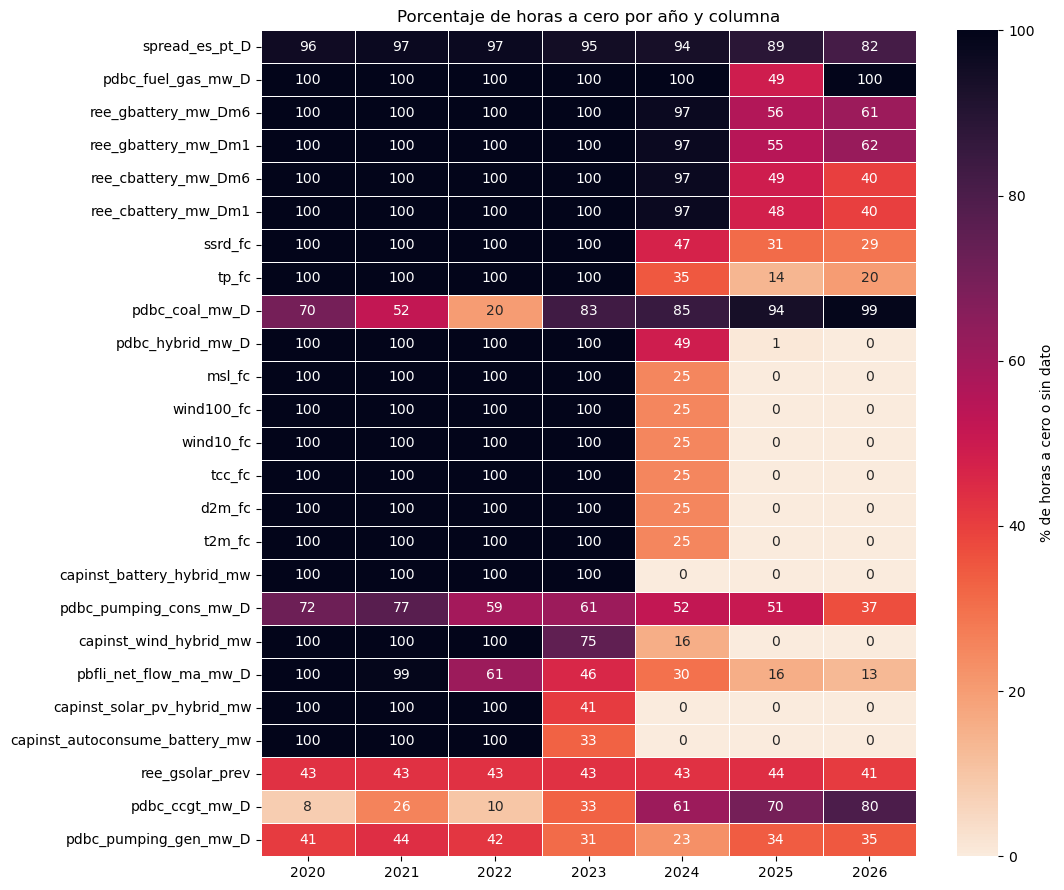

Lo que se busca es la forma de escalón: una fila que empieza oscura y se aclara
de forma monótona no mide su fenómeno, mide el año. Una fila de tono uniforme
entre columnas mide un cero real -- la noche, una central parada.


In [17]:
import seaborn as sns

plt.figure(figsize=(11, 9))
sns.heatmap(tabla.drop(columns=["tendencia"]), annot=True, fmt=".0f",
            cmap="rocket_r", vmin=0, vmax=100, linewidths=0.4,
            cbar_kws={"label": "% de horas a cero o sin dato"})
plt.title("Porcentaje de horas a cero por año y columna")
plt.xlabel(""); plt.tight_layout(); plt.show()

print("Lo que se busca es la forma de escalón: una fila que empieza oscura y se aclara")
print("de forma monótona no mide su fenómeno, mide el año. Una fila de tono uniforme")
print("entre columnas mide un cero real -- la noche, una central parada.")

In [18]:
costes = corte_temporal(perfil, crudo)
base = costes.iloc[0]
costes["columnas_ganadas"] = (costes["columnas_con_serie_completa"]
                              - base["columnas_con_serie_completa"])
costes["filas_train_perdidas"] = base["filas_train"] - costes["filas_train"]
costes["filas_por_columna_ganada"] = (costes["filas_train_perdidas"]
                                      / costes["columnas_ganadas"].replace(0, np.nan)).round(0)
display(costes)
print("DECISIÓN: se descartan columnas, no fechas. En ningún punto de la curva compensa.")

,arranque,columnas_con_serie_completa,filas,pct_filas_perdidas,filas_train,columnas_ganadas,filas_train_perdidas,filas_por_columna_ganada
0,2020-01-02,86,57665,0.0,43843,0,0,NaN
1,2020-01-03,118,57641,0.1,43819,32,24,1.0
2,2020-01-04,128,57617,0.1,43795,42,48,1.0
3,2020-01-08,149,57521,0.3,43699,63,144,2.0
4,2020-07-02,150,53298,7.6,39476,64,4367,68.0
5,2021-02-16,151,47802,17.1,33980,65,9863,152.0
6,2023-03-01,152,29972,48.0,16150,66,27693,420.0
7,2023-05-01,153,28509,50.6,14687,67,29156,435.0
8,2023-06-01,154,27765,51.9,13943,68,29900,440.0
9,2024-01-01,155,22629,60.8,8807,69,35036,508.0


DECISIÓN: se descartan columnas, no fechas. En ningún punto de la curva compensa.


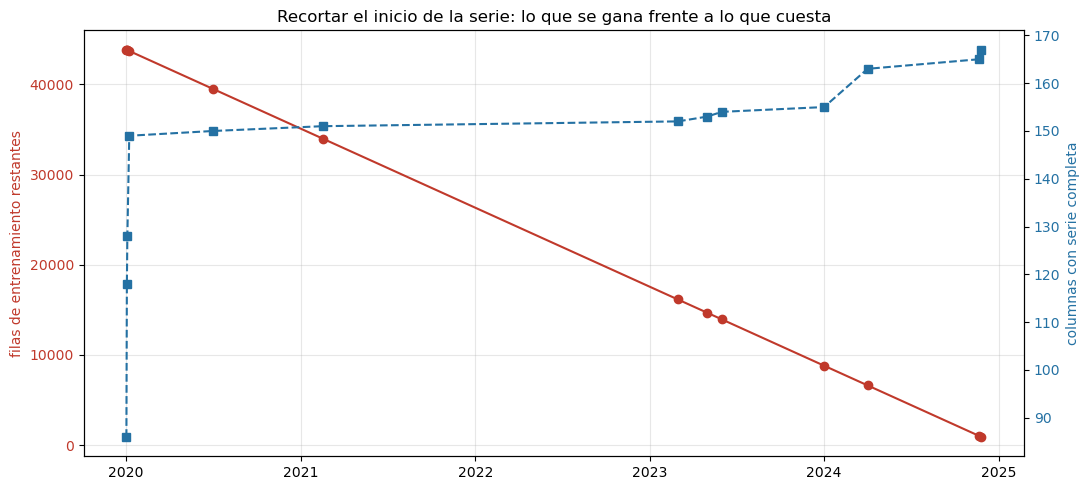

La curva roja cae mucho más deprisa de lo que sube la azul: cada columna
recuperada cuesta miles de filas de entrenamiento.


In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pd.to_datetime(costes["arranque"]), costes["filas_train"], "o-", color="#c0392b")
ax.set_ylabel("filas de entrenamiento restantes", color="#c0392b")
ax.tick_params(axis="y", labelcolor="#c0392b")
ax2 = ax.twinx()
ax2.plot(pd.to_datetime(costes["arranque"]), costes["columnas_con_serie_completa"],
         "s--", color="#2471a3")
ax2.set_ylabel("columnas con serie completa", color="#2471a3")
ax2.tick_params(axis="y", labelcolor="#2471a3")
ax.set_title("Recortar el inicio de la serie: lo que se gana frente a lo que cuesta")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("La curva roja cae mucho más deprisa de lo que sube la azul: cada columna")
print("recuperada cuesta miles de filas de entrenamiento.")

### 12.3 · Las dos podas a la vez

La tabla anterior mide el coste de retrasar el arranque. Pero la decisión real cruza las dos
cosas: para cada fecha de arranque, cuántas columnas sobreviven **si además** se aplica la poda
por serie incompleta.

La lectura corta es la última columna: **cuántas filas de entrenamiento quedan por cada
variable disponible**. Cuanto más alto, menos riesgo de que el modelo memorice en lugar de
aprender. Es la relación entre muestras y parámetros, y es lo que decide.

In [20]:
f_crudo = pd.to_datetime(crudo["fecha_objetivo"])
tr_crudo = crudo["split"] == "train"

rejilla = []
for fecha in costes["arranque"]:
    ts = pd.Timestamp(fecha)
    quedan = f_crudo >= ts
    vivas = perfil[pd.to_datetime(perfil["arranca"]) <= ts]
    n_tr = int((tr_crudo & quedan).sum())
    rejilla.append({"arranque": fecha,
                    "inputs_disponibles": len(vivas),
                    "filas": int(quedan.sum()),
                    "filas_train": n_tr,
                    "train_por_input": round(n_tr / max(len(vivas), 1))})
rejilla = pd.DataFrame(rejilla)
display(rejilla)

mejor = rejilla.loc[rejilla["train_por_input"].idxmax()]
print(f"Máxima relación muestras/variable en el arranque {mejor['arranque']}: "
      f"{mejor['train_por_input']} filas de entrenamiento por variable disponible")
print("\nDECISIÓN: se podan columnas y no fechas. Retrasar el arranque recupera muy pocas")
print("columnas a costa de miles de filas, y la relación muestras/variable no mejora lo")
print("suficiente para compensar la pérdida de historia.")

,arranque,inputs_disponibles,filas,filas_train,train_por_input
0,2020-01-02,86,57665,43843,510
1,2020-01-03,118,57641,43819,371
2,2020-01-04,128,57617,43795,342
3,2020-01-08,149,57521,43699,293
4,2020-07-02,150,53298,39476,263
5,2021-02-16,151,47802,33980,225
6,2023-03-01,152,29972,16150,106
7,2023-05-01,153,28509,14687,96
8,2023-06-01,154,27765,13943,91
9,2024-01-01,155,22629,8807,57


Máxima relación muestras/variable en el arranque 2020-01-02: 510 filas de entrenamiento por variable disponible

DECISIÓN: se podan columnas y no fechas. Retrasar el arranque recupera muy pocas
columnas a costa de miles de filas, y la relación muestras/variable no mejora lo
suficiente para compensar la pérdida de historia.


In [21]:
BAJA_COBERTURA = [c for c in sorted(tardias["variable"]) if c in reg.pool]
ev = {}
for c in BAJA_COBERTURA:
    r = perfil[perfil.variable == c].iloc[0]
    ev[c] = f"la serie arranca el {r['arranca']} · {r['pct_sin_serie']}% de la ventana sin dato"

numericas = [c for c in numericas if c not in BAJA_COBERTURA]
reg.aplicar("Paso 7 · series que arrancan tarde",
            [c for c in reg.pool if c not in BAJA_COBERTURA],
            motivo="cero fabricado: el valor cero funcionaría como indicador del año",
            evidencia=ev,
            nota="algunas se recuperan en la matriz de ventana recortada")


Paso 7 · series que arrancan tarde
  algunas se recuperan en la matriz de ventana recortada

  columnas antes  165   salen   7   entran   0   después  158

  ---- SALEN ----
    -  capinst_battery_hybrid_mw                  cero fabricado: el valor cero funcionaría como indicador del año
                                                  la serie arranca el 2024-01-01 · 60.8% de la ventana sin dato
    -  capinst_solar_pv_hybrid_mw                 cero fabricado: el valor cero funcionaría como indicador del año
                                                  la serie arranca el 2023-06-01 · 51.9% de la ventana sin dato
    -  capinst_wind_hybrid_mw                     cero fabricado: el valor cero funcionaría como indicador del año
                                                  la serie arranca el 2023-03-01 · 48.0% de la ventana sin dato
    -  ree_cbattery_mw_Dm1                        cero fabricado: el valor cero funcionaría como indicador del año
                             

### 12.4 · El caso de las baterías

Cuatro de las columnas que acaban de salir merecen mención propia, porque no son columnas
inútiles: son **columnas sin señal en el tramo donde el modelo aprende y con señal en el tramo
donde va a servir**, que es un problema distinto y peor.

La serie arranca a finales de 2024, de modo que el entrenamiento contiene unas pocas semanas de
dato, y son identificables: dentro del entrenamiento, "batería distinta de cero" equivale
exactamente a "es diciembre de 2024".

**Y la variable sí importa**, que es lo que hace la decisión costosa en lugar de evidente. Se
descarta por desajuste entre entrenamiento y servicio, no por irrelevancia, y debe revertirse en
cuanto el entrenamiento incluya el año de validación.

In [22]:
bat_todas = sorted({c for c in crudo.columns if "battery" in c}
                   | {c for c in datos.columns if "battery" in c})
bat_vivas = [c for c in bat_todas if c in datos.columns]

filas = []
for c in bat_vivas:
    f = {"variable": c}
    for s, m in (("entrenamiento", TRAIN), ("validación", VAL), ("test", TEST)):
        f[f"% != 0 en {s}"] = round(float((datos.loc[m, c] != 0).mean()) * 100, 1)
    f["r con precio (entren.)"] = round(
        float(datos.loc[TRAIN, c].corr(datos.loc[TRAIN, TARGET])), 3)
    f["r con precio (valid.)"] = round(
        float(datos.loc[VAL, c].corr(datos.loc[VAL, TARGET])), 3)
    f["descartada"] = "sí" if c in BAJA_COBERTURA else ""
    filas.append(f)
display(pd.DataFrame(filas))

for c in [c for c in bat_todas if c not in datos.columns]:
    m = reg.libro.get(c, {})
    print(f"  {c:42s} salió en {m.get('sale_en', 'no llegó al pool')}")

,variable,% != 0 en entrenamiento,% != 0 en validación,% != 0 en test,r con precio (entren.),r con precio (valid.),descartada
0,capinst_battery_hybrid_mw,20.2,100.0,100.0,-0.168,0.045,sí
1,ree_cbattery_mw_Dm1,0.6,51.9,60.4,-0.006,0.356,sí
2,ree_cbattery_mw_Dm6,0.6,51.0,59.7,-0.023,0.357,sí
3,ree_gbattery_mw_Dm1,0.6,45.3,38.5,0.020,0.302,sí
4,ree_gbattery_mw_Dm6,0.6,44.4,38.5,0.034,0.294,sí


  capinst_autoconsume_battery_mw             salió en Paso 2 · resolución de valores ausentes


## 13 · Paso 8 — Deriva entre entrenamiento y validación

Las capacidades instaladas son tendencias monótonas: el parque solar crece cada año, el carbón
se retira. Una variable cuyo rango en validación apenas se solapa con el de entrenamiento no se
está prediciendo, se está **extrapolando**.

Se mide como el desplazamiento de la media entre ambos tramos, en desviaciones típicas del
entrenamiento, y **contra validación, nunca contra test**.

**Estas columnas no salen del pool aquí.** Se marcan, y son uno de los criterios que distinguen
la matriz de referencia —que las conserva— de las podadas.

In [23]:
mu, sd = datos.loc[TRAIN, numericas].mean(), datos.loc[TRAIN, numericas].std()
deriva = ((datos.loc[VAL, numericas].mean() - mu) / sd.replace(0, np.nan))
deriva = deriva.dropna().sort_values(key=np.abs, ascending=False)
MUY_DERIVADAS = deriva[deriva.abs() > UMBRAL_DERIVA].index.tolist()

print(f"Columnas con deriva superior a {UMBRAL_DERIVA} sigmas: {len(MUY_DERIVADAS)}\n")
for c in MUY_DERIVADAS:
    print(f"    {c:44s} {deriva[c]:+7.2f} sigmas")
print("\nMarcadas, no eliminadas. El descarte se materializa al componer las matrices.")

Columnas con deriva superior a 3.0 sigmas: 6

    capinst_cogeneration_mw                        -7.68 sigmas
    capinst_other_renewable_mw                     +7.60 sigmas
    capinst_hydro_mw                               -5.87 sigmas
    capinst_total_hybrid_mw                        +3.45 sigmas
    pdbc_hybrid_mw_D                               +3.18 sigmas
    capinst_autoconsume_solar_pv_mw                +3.01 sigmas

Marcadas, no eliminadas. El descarte se materializa al componer las matrices.


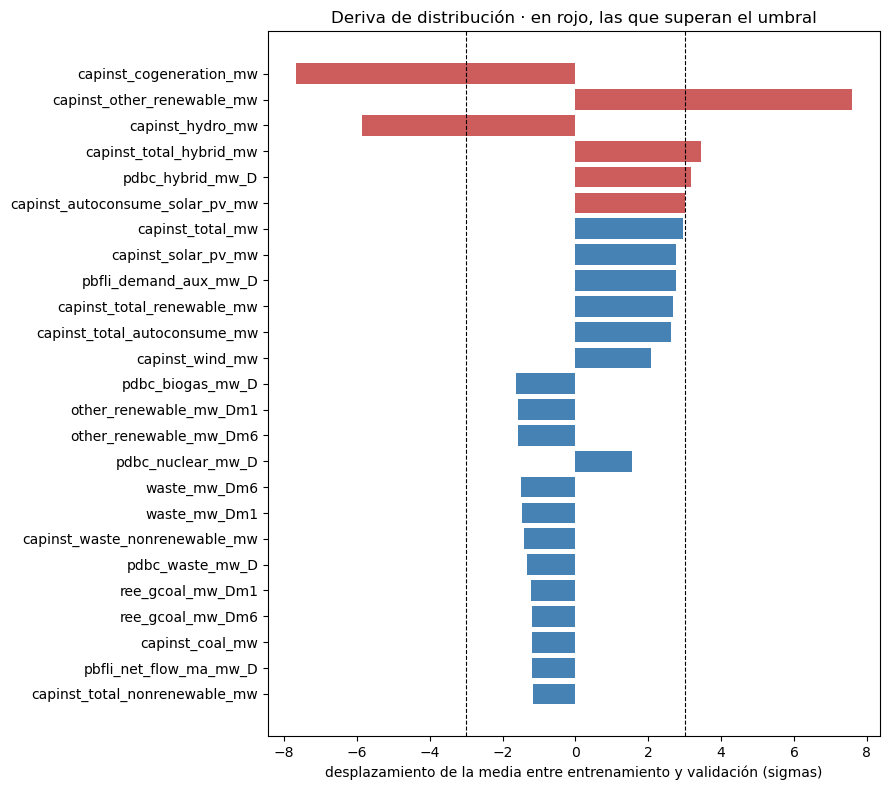

Las líneas discontinuas marcan el umbral. Todo lo que las cruza describe una
variable cuyo rango en validación apenas se solapa con el de entrenamiento.


In [24]:
plt.figure(figsize=(9, 8))
top = deriva.head(25).iloc[::-1]
plt.barh(top.index, top.values,
         color=["indianred" if abs(v) > UMBRAL_DERIVA else "steelblue" for v in top.values])
plt.axvline(UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.axvline(-UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.xlabel("desplazamiento de la media entre entrenamiento y validación (sigmas)")
plt.title("Deriva de distribución · en rojo, las que superan el umbral")
plt.tight_layout(); plt.show()

print("Las líneas discontinuas marcan el umbral. Todo lo que las cruza describe una")
print("variable cuyo rango en validación apenas se solapa con el de entrenamiento.")

## 14 · Paso 9 — Relojes encubiertos

Una columna puede superar el umbral del paso 7 —tener serie durante casi toda la ventana— y aun
así enseñarle al modelo en qué año está, si su proporción de ceros sigue el calendario en lugar
de seguir el fenómeno.

El caso identificado es el saldo de intercambio con uno de los sistemas vecinos: está a cero
durante la mayor parte del entrenamiento y casi nunca en el tramo final.

Se conserva en la matriz de referencia, que por definición no poda nada, y sale de las demás.

In [25]:
RELOJES = [c for c in ["pbfli_net_flow_ma_mw_D"]
           if c in reg.pool and c in crudo.columns]
anio = pd.to_datetime(crudo["fecha_objetivo"]).dt.year
for c in RELOJES:
    z = (crudo[c].isna() | crudo[c].eq(0)).groupby(anio).mean().mul(100).round(0)
    print(f"{c}  —  % de horas a cero o sin dato, por año:")
    print(z.to_frame("% a cero").T.to_string())
print("\nMarcada. El descarte se materializa al componer las matrices.")

pbfli_net_flow_ma_mw_D  —  % de horas a cero o sin dato, por año:
fecha_objetivo   2020  2021  2022  2023  2024  2025  2026
% a cero        100.0  99.0  61.0  46.0  30.0  16.0  13.0

Marcada. El descarte se materializa al componer las matrices.


## 15 · Paso 10 — Redundancia

Cada par de columnas muy correlacionadas es una elección pendiente. De cada par sobrevive la de
mayor asociación con el objetivo, **con dos excepciones en las que el desempate estadístico no
significa nada** y se decide por criterio de dominio:

- **Precios centroeuropeos.** Están acoplados por encima de 0,95 y sus medidas de asociación
  difieren en milésimas. Se conserva **Alemania**, referencia del bloque y mercado al que los
  demás siguen. La información resultante es la misma; lo que cambia es que la elección se puede
  defender.
- **Viento a 10 y a 100 metros.** Se conserva el de **100 metros** porque es la altura de buje
  de un aerogenerador moderno. Como la potencia varía con el cubo de la velocidad, usar la
  altura equivocada no produce un error proporcional.

Antes se apartan las columnas de precio histórico: son características legítimas y muy potentes,
pero si entran en el ranking lo dominan y no deja ver qué aporta el resto.

### 15.1 · El mapa de la redundancia

Antes de decidir qué columna sobrevive de cada par, conviene ver la magnitud del problema. Con
casi doscientas columnas procedentes de fuentes que miden fenómenos relacionados, la
redundancia es masiva y en parte deliberada: dos fuentes para la misma magnitud, un total que
resume sus componentes, un precio y su diferencial.

Los bloques de color intenso fuera de la diagonal son grupos de columnas que dicen
prácticamente lo mismo, y cada uno de ellos es una elección pendiente.

In [26]:
persistencia = [c for c in numericas if c.startswith("es_esios_")]
candidatas   = [c for c in numericas if c not in persistencia]
print(f"Apartadas del ranking (precio histórico): {persistencia}\n")

ranking = dep.ranking_asociacion(datos[TRAIN], candidatas, TARGET)
vc = ranking.set_index("variable")["v_cramer"].to_dict()
redundancia = dep.bloques_correlacion(datos[TRAIN], candidatas, umbral=UMBRAL_REDUNDANCIA)
print(f"Pares con |r| >= {UMBRAL_REDUNDANCIA}: {len(redundancia)}")

PREFERIDAS = ("de_lu_entsoe_D", "wind100_meteo")
RAZON = {"de_lu_entsoe_D": "referencia del bloque centroeuropeo",
         "wind100_meteo": "altura de buje; la potencia va con el cubo de la velocidad"}

DESCARTAR_RED, ev_red = [], {}
for _, fila in redundancia.iterrows():
    a, b = fila.iloc[0], fila.iloc[1]
    r = fila.iloc[2] if len(fila) > 2 else np.nan
    if a in DESCARTAR_RED or b in DESCARTAR_RED:
        continue
    if a in PREFERIDAS and b not in PREFERIDAS:
        gana, pierde, razon = a, b, RAZON[a]
    elif b in PREFERIDAS and a not in PREFERIDAS:
        gana, pierde, razon = b, a, RAZON[b]
    else:
        gana, pierde = (a, b) if vc.get(a, 0) >= vc.get(b, 0) else (b, a)
        razon = (f"mayor asociación ({vc.get(gana, float('nan')):.3f} frente a "
                 f"{vc.get(pierde, float('nan')):.3f})")
    DESCARTAR_RED.append(pierde)
    ev_red[pierde] = f"sobrevive {gana} · |r| = {r:.3f} · {razon}"

DESCARTAR_RED = sorted(set(DESCARTAR_RED))
print(f"\nColumnas marcadas por redundancia: {len(DESCARTAR_RED)}\n")
for c in DESCARTAR_RED:
    print(f"    {c:44s} {ev_red[c]}")

Apartadas del ranking (precio histórico): ['es_esios_D', 'es_esios_Dm1', 'es_esios_Dm6']

Pares con |r| >= 0.95: 52

Columnas marcadas por redundancia: 27

    at_entsoe_D                                  sobrevive ch_entsoe_D · |r| = 0.966 · mayor asociación (0.466 frente a 0.460)
    be_entsoe_D                                  sobrevive de_lu_entsoe_D · |r| = 0.966 · referencia del bloque centroeuropeo
    bil_total_purchases_mw_D                     sobrevive bil_total_sales_mw_D · |r| = 1.000 · mayor asociación (0.192 frente a 0.192)
    bil_total_sales_mw_D                         sobrevive bil_retail_free_buy_mw_D · |r| = 0.996 · mayor asociación (0.203 frente a 0.192)
    capinst_autoconsume_solar_pv_mw              sobrevive capinst_total_autoconsume_mw · |r| = 0.988 · mayor asociación (0.411 frente a 0.409)
    capinst_cogeneration_mw                      sobrevive capinst_wind_mw · |r| = -0.951 · mayor asociación (0.409 frente a 0.367)
    capinst_other_renewable_mw         

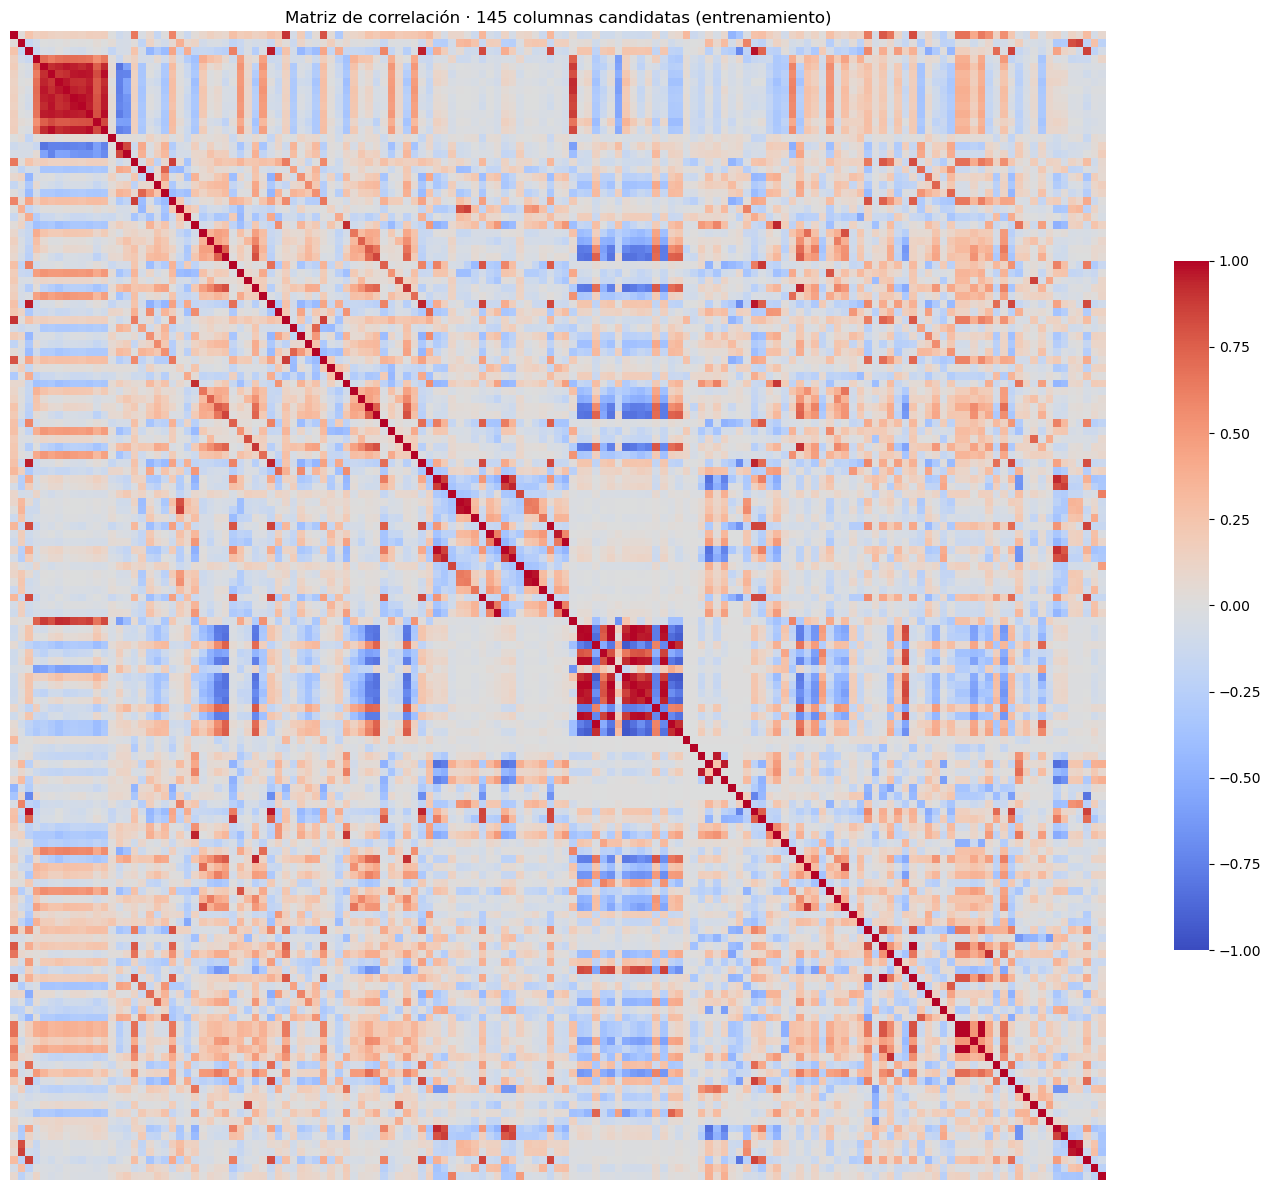

Pares por encima de 0.95: 52 de 10440 posibles


In [27]:
cols_corr = [c for c in candidatas if datos.loc[TRAIN, c].notna().mean() > 0.9]
plt.figure(figsize=(14, 12))
sns.heatmap(datos.loc[TRAIN, cols_corr].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, cbar_kws={"shrink": 0.6},
            xticklabels=False, yticklabels=False)
plt.title(f"Matriz de correlación · {len(cols_corr)} columnas candidatas (entrenamiento)")
plt.tight_layout(); plt.show()

alta = (datos.loc[TRAIN, cols_corr].corr().abs() > UMBRAL_REDUNDANCIA).sum().sum()
n = len(cols_corr)
print(f"Pares por encima de {UMBRAL_REDUNDANCIA}: {(alta - n) // 2} de "
      f"{n * (n - 1) // 2} posibles")

## 16 · Paso 11 — Selección de las 25 de mayor asociación

Único uso del ranking en este notebook: componer la matriz reducida, que responde a si bastan
muy pocas variables. La lectura del ranking como análisis está en el notebook de EDA.

In [28]:
# El conjunto ya depurado, que es sobre el que se selecciona. Si se ordenara sobre todas
# las candidatas y se filtrara despues, el resultado no serian las mejores sino las que
# sobrevivieran de entre ellas, y la matriz acabaria con menos variables de las previstas:
# la pregunta que responde dejaria de ser la que se queria plantear.
PODA = sorted(set(DESCARTAR_RED) | set(MUY_DERIVADAS) | set(RELOJES))
depurado = [c for c in reg.pool
            if c not in COLS_CATEGORICAS + [TARGET] + persistencia and c not in PODA]

MINIMA_INPUTS = (ranking[ranking["variable"].isin(depurado)]
                 .dropna(subset=["v_cramer"])
                 .head(N_MINIMA)["variable"].tolist())

print(f"Conjunto depurado: {len(depurado)} columnas")
print(f"Seleccionadas    : {len(MINIMA_INPUTS)} de mayor asociación\n")
display(ranking[ranking["variable"].isin(MINIMA_INPUTS)]
        [["variable", "v_cramer", "spearman", "pearson"]].round(3)
        .reset_index(drop=True))

descartadas_antes = [x for x in ranking.head(N_MINIMA)["variable"] if x not in depurado]
if descartadas_antes:
    print(f"\nDe las {N_MINIMA} de mayor asociación sobre el conjunto completo, "
          f"{len(descartadas_antes)} no llegan a la selección porque la depuración")
    print("ya las había retirado; su lugar lo ocupan las siguientes del ranking:")
    for x in descartadas_antes:
        m = reg.libro.get(x, {})
        print(f"    {x:38s} {m.get('motivo', 'retirada en la depuración')}")

Conjunto depurado: 114 columnas
Seleccionadas    : 25 de mayor asociación



,variable,v_cramer,spearman,pearson
0,pt_entsoe_D,0.649,0.895,0.918
1,capinst_coal_mw,0.503,-0.154,-0.284
2,capdisp_coal_antracita_mw,0.503,-0.369,-0.331
3,fr_entsoe_D,0.500,0.777,0.669
4,gas_mibgas,0.486,0.752,0.731
5,it_nord_entsoe_D,0.472,0.762,0.658
6,de_lu_entsoe_D,0.431,0.696,0.605
7,pdbc_coal_mw_D,0.418,0.471,0.380
8,capinst_total_autoconsume_mw,0.411,0.165,-0.037
9,capinst_wind_mw,0.409,0.165,0.141



De las 25 de mayor asociación sobre el conjunto completo, 13 no llegan a la selección porque la depuración
ya las había retirado; su lugar lo ocupan las siguientes del ranking:
    be_entsoe_D                            None
    ch_entsoe_D                            None
    at_entsoe_D                            None
    nl_entsoe_D                            None
    capinst_hydro_mw                       None
    cz_entsoe_D                            None
    capinst_total_nonrenewable_mw          None
    capinst_other_renewable_mw             None
    capinst_solar_pv_mw                    None
    capinst_autoconsume_solar_pv_mw        None
    capinst_total_renewable_mw             None
    capinst_total_mw                       None
    capinst_cogeneration_mw                None


### 16.1 · Las tres medidas, y por qué discrepan

El gráfico de la izquierda ordena por V de Cramér, que mide asociación sobre quintiles y capta
relaciones en forma de U o de escalón. El de la derecha ordena por coeficiente de Pearson y
conserva el signo, de modo que se ve la dirección del efecto: en verde las que suben el precio
y en rojo las que lo bajan.

**Que las dos ordenaciones no coincidan es informativo.** Una variable con V de Cramér alto y
Pearson bajo tiene una relación fuerte pero no lineal con el precio, que es exactamente lo que
cabe esperar de la generación renovable: su efecto no es proporcional sino que depende de si
llega o no a desplazar al ciclo combinado de la casación.

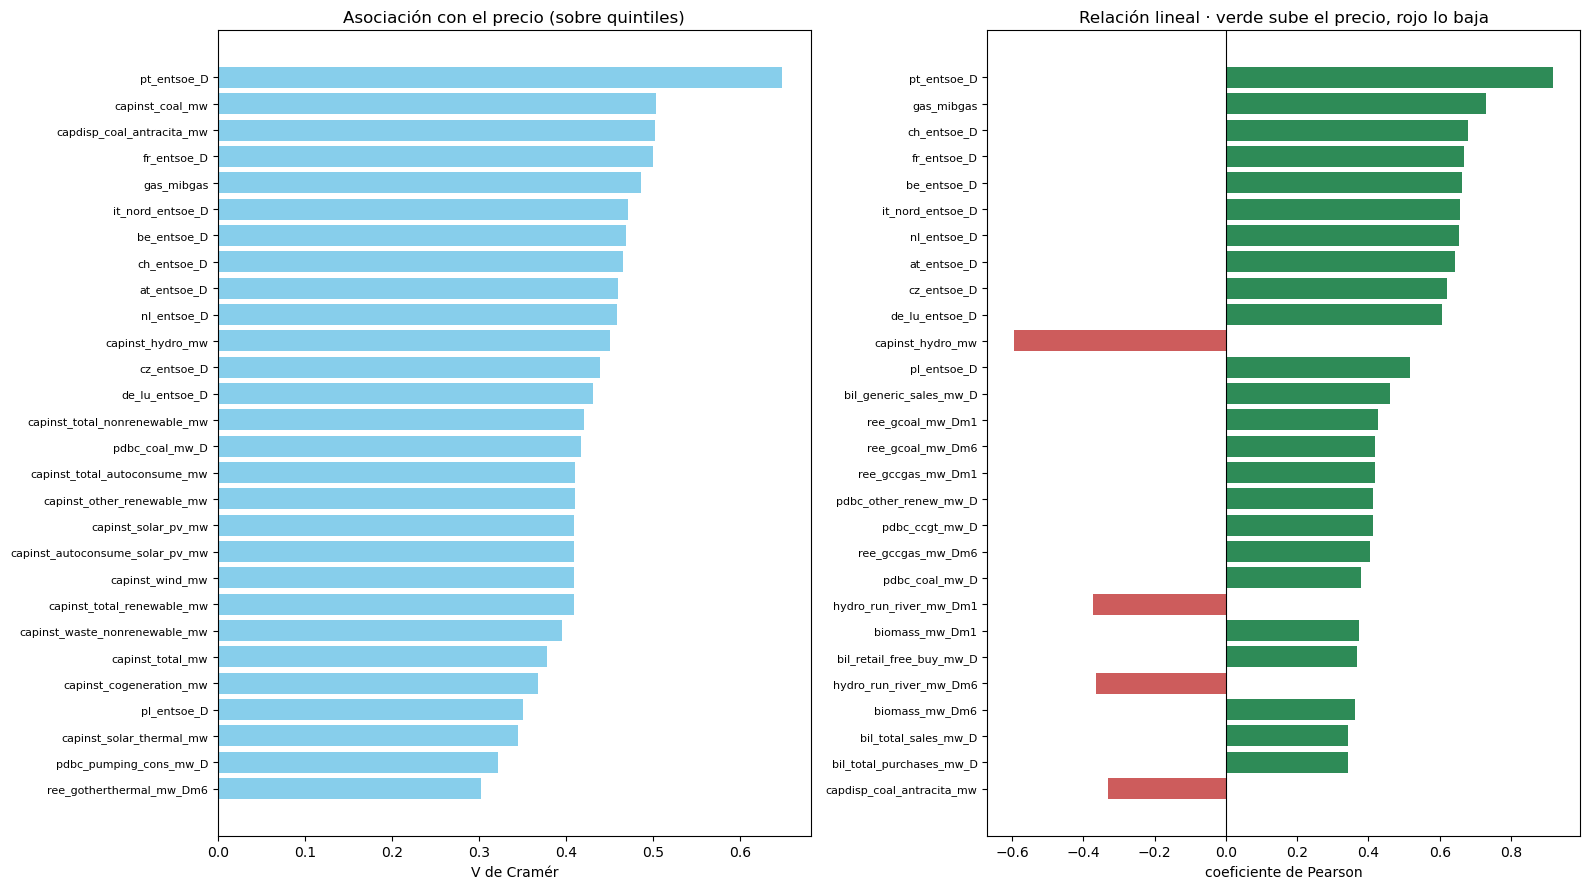

Correlación entre ambas ordenaciones: 0.550

Las que más suben al medir con V de Cramér -- relación no lineal con el precio:


,variable,v_cramer,pearson,rango_vc,rango_pe
16,capinst_other_renewable_mw,0.411,-0.006,17.0,144.0
20,capinst_total_renewable_mw,0.409,0.008,19.5,142.0
17,capinst_solar_pv_mw,0.409,-0.018,19.5,137.0
29,ree_gotherthermal_mw_Dm1,0.293,0.006,30.0,143.0
27,ree_gotherthermal_mw_Dm6,0.303,0.012,28.0,140.0
15,capinst_total_autoconsume_mw,0.411,-0.037,16.0,125.0
30,bil_direct_consumer_mw_D,0.282,-0.042,31.0,124.0
36,oil_mw_Dm1,0.243,0.050,37.0,116.0
60,spread_es_de_D,0.175,0.015,61.0,139.0
22,capinst_total_mw,0.378,-0.068,23.0,94.0


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(16, 9))

top = ranking.dropna(subset=["v_cramer"]).head(28).iloc[::-1]
ax[0].barh(top["variable"], top["v_cramer"], color="skyblue")
ax[0].set_xlabel("V de Cramér")
ax[0].set_title("Asociación con el precio (sobre quintiles)")
ax[0].tick_params(axis="y", labelsize=8)

top_p = ranking.sort_values("abs_pearson", ascending=False).head(28).iloc[::-1]
ax[1].barh(top_p["variable"], top_p["pearson"],
           color=["indianred" if v < 0 else "seagreen" for v in top_p["pearson"]])
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_xlabel("coeficiente de Pearson")
ax[1].set_title("Relación lineal · verde sube el precio, rojo lo baja")
ax[1].tick_params(axis="y", labelsize=8)

plt.tight_layout(); plt.show()

# Cuánto discrepan las dos ordenaciones: si coincidieran, la V de Cramér no aportaría.
r = ranking.dropna(subset=["v_cramer"]).copy()
r["rango_vc"] = r["v_cramer"].rank(ascending=False)
r["rango_pe"] = r["abs_pearson"].rank(ascending=False)
r["salto"] = (r["rango_vc"] - r["rango_pe"]).abs()
print("Correlación entre ambas ordenaciones: "
      f"{r['rango_vc'].corr(r['rango_pe'], method='spearman'):.3f}")
print("\nLas que más suben al medir con V de Cramér -- relación no lineal con el precio:")
display(r.nlargest(10, "salto")[["variable", "v_cramer", "pearson",
                                 "rango_vc", "rango_pe"]].round(3))

### 16.2 · ¿Aportan los bloques recalculados?

Dos bloques se incorporaron con un tratamiento específico: el programa de casación se
reconstruyó desde las tablas del programa base con grano horario, y con él entraron los
componentes de demanda e interconexión programada y los contratos bilaterales.

La pregunta es si ese esfuerzo paga. Se responde comparando la mejor asociación de cada bloque
y su mediana contra la mediana global del conjunto candidato: un bloque cuya mediana esté por
debajo de la global aporta menos que una columna elegida al azar.

In [30]:
BLOQUES_NUEVOS = {
    "pdbc_  · casación por tecnología":       "pdbc_",
    "pbfli_ · demanda e interconexión":       "pbfli_",
    "bil_   · contratos bilaterales":         "bil_",
}
rk = ranking.reset_index(drop=True)
mediana_global = rk["v_cramer"].median()
print(f"mediana de asociación del conjunto candidato: {mediana_global:.3f}\n")

for etiqueta, pre in BLOQUES_NUEVOS.items():
    sub = rk[rk["variable"].str.startswith(pre)]
    if not len(sub):
        print(f"{etiqueta}: ninguna columna en el conjunto\n")
        continue
    mejor = sub.loc[sub["v_cramer"].idxmax()]
    pos = int(rk.index[rk["variable"] == mejor["variable"]][0]) + 1
    print(f"{etiqueta}")
    print(f"    columnas          : {len(sub)}")
    print(f"    mejor asociación  : {mejor['v_cramer']:.3f}  ({mejor['variable']})")
    print(f"    su puesto global  : {pos} de {len(rk)}")
    print(f"    mediana del bloque: {sub['v_cramer'].median():.3f}   "
          f"{'por encima' if sub['v_cramer'].median() > mediana_global else 'por debajo'}"
          f" de la global")
    print()

nuevos = rk[rk["variable"].str.startswith(tuple(BLOQUES_NUEVOS.values()))]
display(nuevos.head(15)[["variable", "v_cramer", "pearson"]].round(3)
        .reset_index(drop=True))

mediana de asociación del conjunto candidato: 0.148

pdbc_  · casación por tecnología
    columnas          : 18
    mejor asociación  : 0.418  (pdbc_coal_mw_D)
    su puesto global  : 15 de 145
    mediana del bloque: 0.199   por encima de la global

pbfli_ · demanda e interconexión
    columnas          : 10
    mejor asociación  : 0.194  (pbfli_demand_aux_mw_D)
    su puesto global  : 55 de 145
    mediana del bloque: 0.103   por debajo de la global

bil_   · contratos bilaterales
    columnas          : 8
    mejor asociación  : 0.282  (bil_direct_consumer_mw_D)
    su puesto global  : 31 de 145
    mediana del bloque: 0.192   por encima de la global



,variable,v_cramer,pearson
0,pdbc_coal_mw_D,0.418,0.380
1,pdbc_pumping_cons_mw_D,0.322,0.274
2,pdbc_ccgt_mw_D,0.296,0.413
3,bil_direct_consumer_mw_D,0.282,-0.042
4,pdbc_other_renew_mw_D,0.255,0.413
5,bil_generic_sales_mw_D,0.242,0.462
6,pdbc_cogen_mw_D,0.239,0.056
7,pdbc_hydro_no_ugh_mw_D,0.233,-0.315
8,pdbc_nuclear_mw_D,0.229,-0.254
9,pdbc_biogas_mw_D,0.218,0.288


# PARTE III · Las matrices finales

## 17 · Composición

Cuatro matrices, con un diseño **deliberadamente experimental**: tres varían las columnas
manteniendo fija la ventana temporal, y la cuarta varía la ventana manteniendo fijas las
columnas. Así cada comparación aísla un único factor y una diferencia de error puede atribuirse
a una causa; si se movieran las dos cosas a la vez, un resultado mejor no diría de dónde viene.

| matriz | ventana | columnas | pregunta que responde |
|---|---|---|---|
| **completa** | serie entera | todo el conjunto candidato | referencia: no poda nada |
| **nucleo** | serie entera | sin redundantes, derivadas ni relojes | ¿sobran variables? |
| **minima** | serie entera | las 25 de mayor asociación | ¿bastan muy pocas? |
| **moderna** | recortada | las del núcleo | ¿estorba el régimen de precios antiguo? |

La última merece justificación: una parte importante del entrenamiento pertenece a un régimen de
precios que no volverá, y un modelo ajustado sobre él aprende ese régimen tanto como el mercado.
La fecha de corte se eligió midiendo, no por criterio: es la que menos confusión introduce entre
fecha y precio.

In [31]:
completa_inputs = [c for c in reg.pool
                   if c not in COLS_CATEGORICAS + [TARGET] + persistencia]
nucleo_inputs   = [c for c in completa_inputs if c not in PODA]
# `MINIMA_INPUTS` ya se eligio sobre el conjunto depurado, asi que no se refiltra:
# hacerlo aqui reduciria la matriz por debajo del tamaño que se quiere probar.
minima_inputs   = list(MINIMA_INPUTS)
moderna_inputs  = list(nucleo_inputs)

assert len(minima_inputs) == N_MINIMA, (
    f"la matriz minima tiene {len(minima_inputs)} columnas y deberia tener {N_MINIMA}")

MATRICES = {"completa": completa_inputs, "nucleo": nucleo_inputs,
            "minima": minima_inputs, "moderna": moderna_inputs}

display(pd.DataFrame([{
    "matriz": n, "columnas de entrada": len(i),
    "ventana": "recortada" if n == "moderna" else "serie entera",
    "factor que aísla": {"completa": "ninguno (referencia)",
                         "nucleo": "columnas — ¿sobran variables?",
                         "minima": f"columnas — ¿bastan {N_MINIMA}?",
                         "moderna": "ventana — ¿estorba el régimen antiguo?"}[n],
} for n, i in MATRICES.items()]))

print("Composición de cada matriz por bloque:")
bl = mapa.set_index("variable")["bloque"]
comp = pd.concat({n: pd.Series(i).map(bl).value_counts() for n, i in MATRICES.items()},
                 axis=1).fillna(0).astype(int)
display(comp)

,matriz,columnas de entrada,ventana,factor que aísla
0,completa,145,serie entera,ninguno (referencia)
1,nucleo,114,serie entera,columnas — ¿sobran variables?
2,minima,25,serie entera,columnas — ¿bastan 25?
3,moderna,114,recortada,ventana — ¿estorba el régimen antiguo?


Composición de cada matriz por bloque:


,completa,nucleo,minima,moderna
programas de casación,36,30,6,30
estado real de días anteriores,32,32,8,32
meteorología: reanálisis desfasado,18,12,0,12
capacidad instalada,14,4,4,4
precio: mercados vecinos,10,5,5,5
calendario: codificación cíclica,8,6,0,6
meteorología: canal empalmado,7,6,0,6
capacidad disponible,5,5,1,5
demanda e intercambios: agregado,4,4,0,4
generación: reconstruida entre fuentes,4,3,0,3


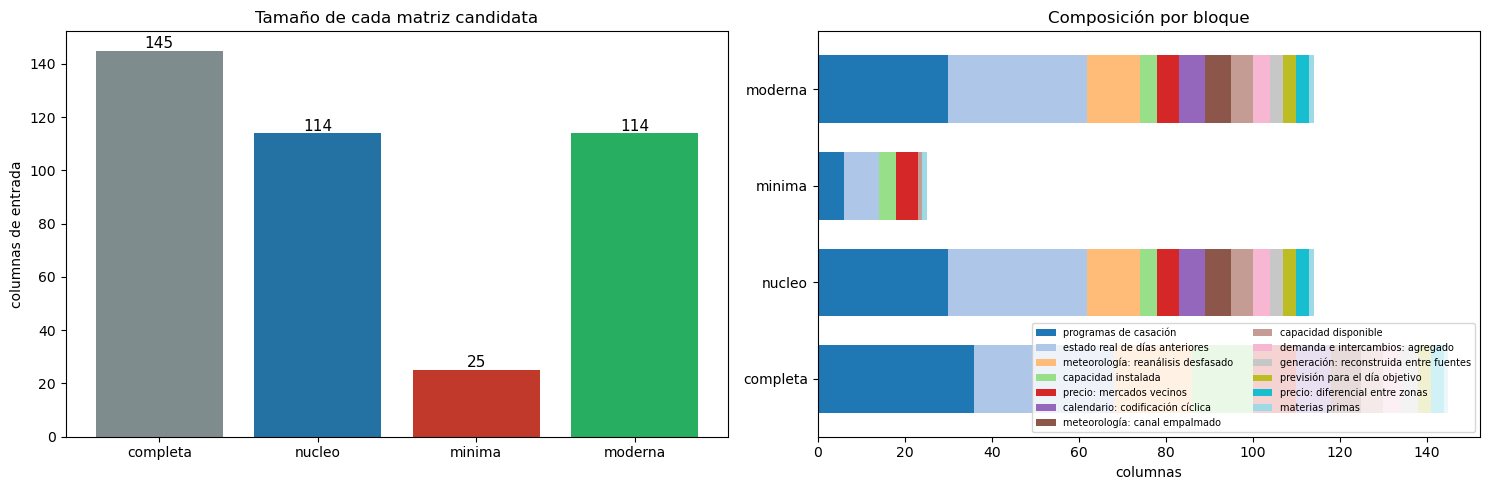

La comparación entre `completa` y `nucleo` aísla el efecto de podar columnas;
la de `nucleo` contra `moderna`, el de recortar la ventana temporal.


In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

n = pd.Series({k: len(v) for k, v in MATRICES.items()})
ax[0].bar(n.index, n.values, color=["#7f8c8d", "#2471a3", "#c0392b", "#27ae60"])
for i, v in enumerate(n.values):
    ax[0].text(i, v + 1, str(v), ha="center", fontsize=11)
ax[0].set_ylabel("columnas de entrada")
ax[0].set_title("Tamaño de cada matriz candidata")

comp.T.plot(kind="barh", stacked=True, ax=ax[1], colormap="tab20", width=0.7)
ax[1].set_xlabel("columnas"); ax[1].set_title("Composición por bloque")
ax[1].legend(fontsize=7, ncol=2, loc="lower right")

plt.tight_layout(); plt.show()

print("La comparación entre `completa` y `nucleo` aísla el efecto de podar columnas;")
print("la de `nucleo` contra `moderna`, el de recortar la ventana temporal.")

### 17.1 · Qué columna sale de qué matriz, y por qué

La tabla que responde a *"¿por qué no está esta columna?"* sin recorrer el notebook. Se exporta
junto a las matrices.

El cruce entre regla y bloque es la comprobación importante: **si una regla se ceba con un
bloque concreto, conviene mirarlo**, porque suele indicar un problema sistemático de esa fuente
y no una propiedad de las columnas.

In [33]:
REGLAS = [
    (f"redundante (|r| ≥ {UMBRAL_REDUNDANCIA})", DESCARTAR_RED,
     "otra columna lleva la misma información", "nucleo, minima, moderna"),
    (f"deriva superior a {UMBRAL_DERIVA} sigmas", MUY_DERIVADAS,
     "la distribución se desplaza tanto que el modelo estaría extrapolando",
     "nucleo, minima, moderna"),
    ("reloj encubierto", RELOJES,
     "su proporción de ceros sigue el calendario, no el fenómeno",
     "nucleo, minima, moderna"),
]
filas = []
for regla, cols, motivo, afecta in REGLAS:
    for c in sorted(set(cols)):
        filas.append({"variable": c, "bloque": bl.get(c, ""), "regla": regla,
                      "motivo": motivo, "evidencia": ev_red.get(c, ""),
                      "fuera_de": afecta})
decisiones = pd.DataFrame(filas)

if len(decisiones):
    print("Descartes por regla:")
    print(decisiones.groupby("regla").size().rename("columnas").to_string())
    print("\nCruce entre regla y bloque:")
    print(pd.crosstab(decisiones["bloque"], decisiones["regla"]).to_string())
    print()
    display(decisiones.sort_values(["regla", "variable"]).reset_index(drop=True))
    decisiones.to_csv(SALIDA / "decisiones_por_matriz.csv", index=False, encoding="utf-8")

Descartes por regla:
regla
deriva superior a 3.0 sigmas     6
redundante (|r| ≥ 0.95)         27
reloj encubierto                 1

Cruce entre regla y bloque:
regla                                   deriva superior a 3.0 sigmas  redundante (|r| ≥ 0.95)  reloj encubierto
bloque                                                                                                         
calendario: codificación cíclica                                   0                        2                 0
capacidad instalada                                                5                        8                 0
generación: reconstruida entre fuentes                             0                        1                 0
meteorología: canal empalmado                                      0                        1                 0
meteorología: reanálisis desfasado                                 0                        6                 0
precio: mercados vecinos                               

,variable,bloque,regla,motivo,evidencia,fuera_de
0,capinst_autoconsume_solar_pv_mw,capacidad instalada,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,sobrevive capinst_total_autoconsume_mw · |r| =...,"nucleo, minima, moderna"
1,capinst_cogeneration_mw,capacidad instalada,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,sobrevive capinst_wind_mw · |r| = -0.951 · may...,"nucleo, minima, moderna"
2,capinst_hydro_mw,capacidad instalada,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,,"nucleo, minima, moderna"
3,capinst_other_renewable_mw,capacidad instalada,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,sobrevive capinst_total_autoconsume_mw · |r| =...,"nucleo, minima, moderna"
4,capinst_total_hybrid_mw,capacidad instalada,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,,"nucleo, minima, moderna"
5,pdbc_hybrid_mw_D,programas de casación,deriva superior a 3.0 sigmas,la distribución se desplaza tanto que el model...,,"nucleo, minima, moderna"
6,at_entsoe_D,precio: mercados vecinos,redundante (|r| ≥ 0.95),otra columna lleva la misma información,sobrevive ch_entsoe_D · |r| = 0.966 · mayor as...,"nucleo, minima, moderna"
7,be_entsoe_D,precio: mercados vecinos,redundante (|r| ≥ 0.95),otra columna lleva la misma información,sobrevive de_lu_entsoe_D · |r| = 0.966 · refer...,"nucleo, minima, moderna"
8,bil_total_purchases_mw_D,programas de casación,redundante (|r| ≥ 0.95),otra columna lleva la misma información,sobrevive bil_total_sales_mw_D · |r| = 1.000 ·...,"nucleo, minima, moderna"
9,bil_total_sales_mw_D,programas de casación,redundante (|r| ≥ 0.95),otra columna lleva la misma información,sobrevive bil_retail_free_buy_mw_D · |r| = 0.9...,"nucleo, minima, moderna"


## 18 · El libro mayor

**La tabla que responde a todo.** Una fila por cada columna que ha existido en algún momento:
su bloque, su tabla de origen, si se construyó aquí y para qué, su estado final, el paso en que
salió, el motivo, la evidencia, y en qué matrices aparece.

Es el documento que acompaña a la memoria y el que permite auditar el proceso sin ejecutarlo.

In [34]:
libro = reg.libro_mayor(destinos=MATRICES)
display(libro)
libro.to_csv(SALIDA / "libro_mayor_columnas.csv", index=False, encoding="utf-8")
print(f"exportado  ->  {SALIDA / 'libro_mayor_columnas.csv'}   ({len(libro)} filas)")

print("\nResumen por estado:")
print(libro.groupby("estado").size().rename("columnas").to_string())
print("\nDescartes agrupados por motivo:")
print(libro[libro["estado"] == "descartada"].groupby("motivo").size()
      .rename("columnas").sort_values(ascending=False).to_string())

,variable,bloque,tabla_origen,estado,entra_en,proposito,sale_en,motivo,evidencia,en_completa,en_nucleo,en_minima,en_moderna
169,capdisp_fuel_mw,capacidad disponible,esios_capacity_available,descartada,matriz de partida,potencia declarada disponible por tecnología,Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
104,capinst_autoconsume_battery_mw,capacidad instalada,esios_capacity_installed,descartada,matriz de partida,"parque disponible, de evolución estructural",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
108,capinst_ccgt_mw,capacidad instalada,esios_capacity_installed,descartada,matriz de partida,"parque disponible, de evolución estructural",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
107,capinst_fuel_mw,capacidad instalada,esios_capacity_installed,descartada,matriz de partida,"parque disponible, de evolución estructural",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
105,capinst_nuclear_mw,capacidad instalada,esios_capacity_installed,descartada,matriz de partida,"parque disponible, de evolución estructural",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
93,capinst_pump_mw,capacidad instalada,esios_capacity_installed,descartada,matriz de partida,"parque disponible, de evolución estructural",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,retirada durante la resolución de ausentes,,,,
171,d2m_fc,meteorología: previsión cruda,ecmwf_forecast_agg (prevision D+1),descartada,matriz de partida,"previsión original, sustituida por el canal em...",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,la sustituye d2m_meteo,,,,
177,msl_fc,meteorología: previsión cruda,ecmwf_forecast_agg (prevision D+1),descartada,matriz de partida,"previsión original, sustituida por el canal em...",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,la sustituye msl_meteo,,,,
174,ssrd_fc,meteorología: previsión cruda,ecmwf_forecast_agg (prevision D+1),descartada,matriz de partida,"previsión original, sustituida por el canal em...",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,la sustituye ssrd_meteo,,,,
170,t2m_fc,meteorología: previsión cruda,ecmwf_forecast_agg (prevision D+1),descartada,matriz de partida,"previsión original, sustituida por el canal em...",Paso 2 · resolución de valores ausentes,sustituida por el canal meteorológico empalmad...,la sustituye t2m_meteo,,,,


exportado  ->  c:\Users\torgi\proyectos\tfm-energia\data\gold\libro_mayor_columnas.csv   (188 filas)

Resumen por estado:
estado
descartada       30
en la matriz    158

Descartes agrupados por motivo:
motivo
sustituida por el canal meteorológico empalmado, que cubre toda la serie    14
cero fabricado: el valor cero funcionaría como indicador del año             7
bandera de trazabilidad: metadato de la fila, no una característica          4
no está archivada en la fuente de previsión que alimenta producción          2
constante en entrenamiento                                                   1
identidad exacta con otras columnas de la matriz                             1
cuasi-constante en entrenamiento                                             1


### 18.1 · El recorrido, paso a paso

In [35]:
pasos = reg.resumen_pasos()
pasos["balance"] = pasos["entran"] - pasos["salen"]
display(pasos[["paso", "antes", "salen", "entran", "despues", "balance"]])

print(f"De {pasos.iloc[0]['antes']} columnas candidatas se llega a "
      f"{len(completa_inputs)} entradas en la matriz de referencia y "
      f"{len(nucleo_inputs)} en la podada.")

,paso,antes,salen,entran,despues,balance
0,Paso 0 · alcance del bloque de materias primas,186,0,0,186,0
1,Paso 1 · reparación del cero de suministro,186,0,2,188,2
2,Paso 2 · resolución de valores ausentes,188,14,0,174,-14
3,Paso 3 · tipado,174,4,0,170,-4
4,Paso 4 · columnas sin varianza,170,2,0,168,-2
5,Paso 5 · colinealidad exacta,168,1,0,167,-1
6,Paso 6 · sin equivalente en producción,167,2,0,165,-2
7,Paso 7 · series que arrancan tarde,165,7,0,158,-7


De 186 columnas candidatas se llega a 145 entradas en la matriz de referencia y 114 en la podada.


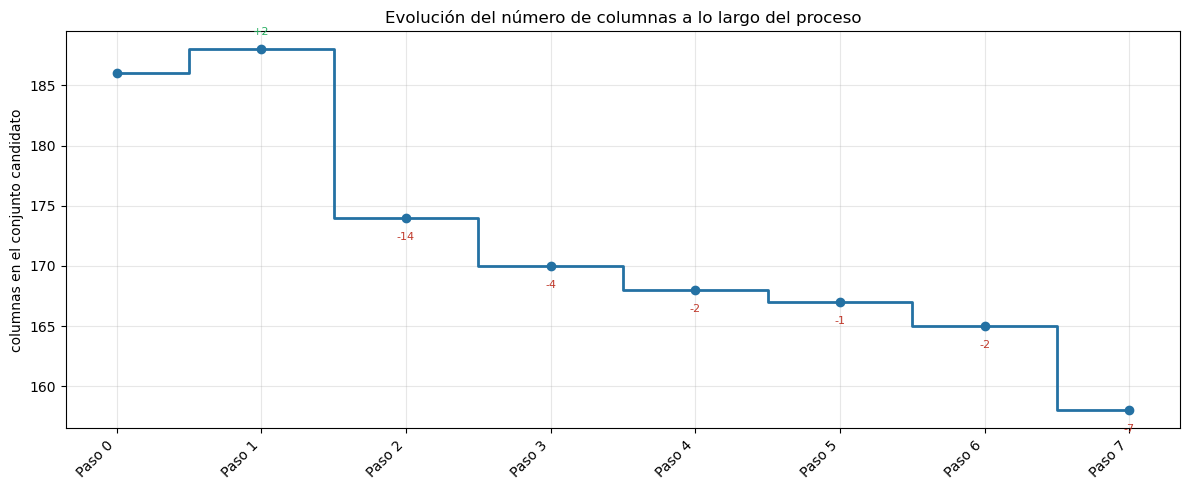

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.step(range(len(pasos)), pasos["despues"], where="mid", color="#2471a3", lw=2)
ax.scatter(range(len(pasos)), pasos["despues"], color="#2471a3", zorder=3)
for i, r in pasos.iterrows():
    if r["salen"]:
        ax.annotate(f"-{r['salen']}", (i, r["despues"]), textcoords="offset points",
                    xytext=(0, -16), ha="center", fontsize=8, color="#c0392b")
    if r["entran"]:
        ax.annotate(f"+{r['entran']}", (i, r["despues"]), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8, color="#27ae60")
ax.set_xticks(range(len(pasos)))
ax.set_xticklabels([p.split("·")[0].strip() for p in pasos["paso"]],
                   rotation=45, ha="right")
ax.set_ylabel("columnas en el conjunto candidato")
ax.set_title("Evolución del número de columnas a lo largo del proceso")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 19 · Comprobaciones

Cuatro, y todas tienen que pasar antes de exportar. Existen para que un fallo del proceso se
manifieste como un error visible y no como una matriz silenciosamente equivocada.

In [37]:
ok = True

print("[1] Ninguna columna descartada sin motivo asignado")
sin_motivo = libro[(libro["estado"] == "descartada")
                   & (libro["motivo"].fillna("") == "SIN MOTIVO")]["variable"].tolist()
print(f"    descartes sin motivo: {len(sin_motivo)}")
if sin_motivo:
    ok = False
    print(f"    FALLA  ->  {sin_motivo}")

print("\n[2] Toda columna ausente del núcleo tiene una regla que lo explica")
explicadas = set(decisiones["variable"]) if len(decisiones) else set()
explicadas |= set(libro[libro["estado"] == "descartada"]["variable"])
huerfanas = [c for c in completa_inputs if c not in nucleo_inputs and c not in explicadas]
print(f"    columnas sin regla: {len(huerfanas)}")
if huerfanas:
    ok = False
    print(f"    FALLA  ->  {huerfanas}")

print("\n[3] El bloque de materias primas se limita al alcance definido")
sobran_com = sorted({c for cols in MATRICES.values() for c in cols
                     if es_commodity(c) and c not in COMMODITIES})
print(f"    columnas fuera de alcance: {len(sobran_com)}")
if sobran_com:
    ok = False
    print(f"    FALLA  ->  {sobran_com}")
else:
    print(f"    conservada: {COMMODITIES}")

print("\n[4] Ninguna decisión ha consultado el tramo de test")
for k, v in {"varianza": "entrenamiento",
             "colinealidad": "serie completa (identidad algebraica)",
             "deriva": "entrenamiento frente a validación",
             "series que arrancan tarde": "matriz previa a la imputación",
             "redundancia y asociación": "entrenamiento"}.items():
    print(f"    {k:30s} {v}")
print(f"\n    filas de test en los ficheros: {int(TEST.sum()):,} (viajan, no se consultan)")

print("\n" + ("TODAS LAS COMPROBACIONES PASAN." if ok
               else "HAY COMPROBACIONES QUE FALLAN — revisar antes de exportar."))

[1] Ninguna columna descartada sin motivo asignado
    descartes sin motivo: 0

[2] Toda columna ausente del núcleo tiene una regla que lo explica
    columnas sin regla: 0

[3] El bloque de materias primas se limita al alcance definido
    columnas fuera de alcance: 0
    conservada: ['gas_mibgas']

[4] Ninguna decisión ha consultado el tramo de test
    varianza                       entrenamiento
    colinealidad                   serie completa (identidad algebraica)
    deriva                         entrenamiento frente a validación
    series que arrancan tarde      matriz previa a la imputación
    redundancia y asociación       entrenamiento

    filas de test en los ficheros: 5,063 (viajan, no se consultan)

TODAS LAS COMPROBACIONES PASAN.


## 20 · Exportación

Cada matriz se sella con una **huella criptográfica** calculada sobre su contenido y sus nombres
de columna. Las matrices evolucionan mientras se depura y todas se llaman igual, de modo que un
resultado de entrenamiento suelto no puede atribuirse con seguridad a una versión concreta. Con
el sello, dos matrices con la misma huella son necesariamente la misma, y un registro que
declare otra huella indica que hay que reentrenar.

In [38]:
COMUNES = COLS_CONTROL + [TARGET] + persistencia + COLS_CATEGORICAS + COLS_BANDERA
FILAS = {n: (datos["fecha_objetivo"] >= CORTE_MODERNA) if n == "moderna"
            else pd.Series(True, index=datos.index) for n in MATRICES}

sellos = []
for nombre, inputs in MATRICES.items():
    cols = list(dict.fromkeys([c for c in COMUNES + inputs if c in datos.columns]))
    m = datos.loc[FILAS[nombre], cols].copy()
    ruta = SALIDA / f"matriz_{nombre}.parquet"
    m.to_parquet(ruta, index=False)

    h = hashlib.sha256()
    h.update("|".join(cols).encode())
    h.update(pd.util.hash_pandas_object(m, index=False).values.tobytes())
    huella = h.hexdigest()[:8]

    # CSV junto al parquet: el parquet es el formato de trabajo -- conserva tipos y pesa
    # la cuarta parte -- pero el CSV se abre sin dependencias y sirve de respaldo cuando
    # la version de pyarrow que lo escribio no coincide con la que intenta leerlo.
    try:
        m.to_csv(ruta.with_suffix(".csv"), index=False, encoding="utf-8")
    except PermissionError:
        print(f"  AVISO: matriz_{nombre}.csv esta bloqueado; el parquet SI se escribio.")

    # Contrato de columnas. El constructor de la matriz de produccion se reindexa contra
    # este catalogo para garantizar que el modelo recibe exactamente las columnas con las
    # que se entreno, en el mismo orden. Sin el, aborta.
    pd.DataFrame({"variable": cols,
                  "es_entrada": [x in inputs for x in cols]}).to_csv(
        SALIDA / f"matriz_{nombre}_columnas.csv", index=False, encoding="utf-8")

    # Metadatos de la matriz, que produccion lee para heredar las fronteras de la
    # particion sin tener que recalcularlas.
    (SALIDA / f"matriz_{nombre}.meta.json").write_text(json.dumps({
        "nombre": nombre,
        "hash": huella,
        "generada": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
        "filas": len(m), "columnas": len(cols), "entradas": len(inputs),
        "ventana": f"{m.fecha_objetivo.min():%Y-%m-%d} -> {m.fecha_objetivo.max():%Y-%m-%d}",
        "train_end": str(datos.loc[datos.split == "train", "fecha_pred"].max().date()),
        "val_end": str(datos.loc[datos.split == "validation", "fecha_pred"].max().date()),
        "valores_ausentes": int(m.isna().sum().sum()),
    }, indent=2, ensure_ascii=False), encoding="utf-8")

    sellos.append({"matriz": nombre, "huella": huella, "filas": len(m),
                   "columnas": len(cols), "entradas": len(inputs),
                   "desde": str(m["fecha_objetivo"].min().date()),
                   "hasta": str(m["fecha_objetivo"].max().date()),
                   "valores ausentes": int(m.isna().sum().sum())})

sellos = pd.DataFrame(sellos)
display(sellos)
sellos.to_csv(SALIDA / "sellos_matrices.csv", index=False, encoding="utf-8")

print("\nFicheros generados por matriz:")
print("  matriz_{nombre}.parquet            formato de trabajo")
print("  matriz_{nombre}.csv                respaldo legible sin dependencias")
print("  matriz_{nombre}_columnas.csv       contrato de columnas para produccion")
print("  matriz_{nombre}.meta.json          huella, ventana y fronteras de la particion")
print("\nY del proceso completo:")
print("  mapa_columnas_matriz_partida.csv   bloque, naturaleza y disponibilidad de partida")
print("  libro_mayor_columnas.csv           una fila por columna, con su destino")
print("  decisiones_por_matriz.csv          que regla saca cada columna de que matriz")
print("  resolucion_ausentes_por_columna.csv  por que via se resolvio cada hueco")
print("  sellos_matrices.csv                huella de contenido de cada matriz")

,matriz,huella,filas,columnas,entradas,desde,hasta,valores ausentes
0,completa,645f7cd8,57521,166,145,2020-01-08,2026-07-31,0
1,nucleo,35bf390e,57521,135,114,2020-01-08,2026-07-31,0
2,minima,850d4726,57521,46,25,2020-01-08,2026-07-31,0
3,moderna,34864bd7,31388,135,114,2023-01-01,2026-07-31,0



Ficheros generados por matriz:
  matriz_{nombre}.parquet            formato de trabajo
  matriz_{nombre}.csv                respaldo legible sin dependencias
  matriz_{nombre}_columnas.csv       contrato de columnas para produccion
  matriz_{nombre}.meta.json          huella, ventana y fronteras de la particion

Y del proceso completo:
  mapa_columnas_matriz_partida.csv   bloque, naturaleza y disponibilidad de partida
  libro_mayor_columnas.csv           una fila por columna, con su destino
  decisiones_por_matriz.csv          que regla saca cada columna de que matriz
  resolucion_ausentes_por_columna.csv  por que via se resolvio cada hueco
  sellos_matrices.csv                huella de contenido de cada matriz


## 21 · Cuestiones abiertas

1. **El canal meteorológico admite un modo que constituiría fuga.** El constructor permite
   alimentar la matriz con la meteorología real del día objetivo, útil para medir la cota
   superior alcanzable con meteorología perfecta, pero inutilizable para el modelo de
   producción. Este notebook usa únicamente el modo desfasado.

2. **El alineamiento del bloque de programas** admite dos versiones, una más conservadora que la
   otra respecto al momento de publicación. Pendiente de fijar.

3. **Las columnas de baterías deben reincorporarse** en cuanto el entrenamiento incluya el año de
   validación. Su descarte responde a una limitación de la ventana, no a una propiedad de la
   variable.

